# Log-rank Test para Colapso de Categorias

**Objetivo:** usar o log-rank test para identificar quais níveis de uma variável categórica
têm curvas de sobrevivência estatisticamente iguais — e portanto podem ser colapsados.

**Caso de uso:** variável `uf` com 10 estados, onde alguns têm perfis de risco similares
e outros claramente diferentes. O dataset é construído artificialmente para que você
saiba de antemão qual é a resposta certa e possa validar se a função encontra.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import unittest
import io
from itertools import combinations
from scipy.stats import chi2
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import squareform
from typing import Dict, List, Optional, Tuple

from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test, multivariate_logrank_test

plt.style.use('seaborn-v0_8-whitegrid')
PALETTE = ['#2196F3','#E91E63','#4CAF50','#FF9800','#9C27B0',
           '#00BCD4','#FF5722','#607D8B','#8BC34A','#FFC107']
np.random.seed(42)
print('✅ Setup OK')

✅ Setup OK


## 1. Dataset Sintético — UFs com grupos de risco conhecidos

Construímos o dataset com **três grupos de risco conhecidos** e tamanhos de amostra
intencionalmente diferentes por UF.
Isso nos permite validar se a função recupera a estrutura verdadeira.

```
Grupo BAIXO risco  → SP, MG, RS        (escala Weibull alta → sobrevive mais)
Grupo MÉDIO risco  → RJ, PR, SC        (escala intermediária)
Grupo ALTO risco   → BA, CE, PE, AM    (escala baixa → default mais rápido)

Tamanhos propositalmente desiguais:
  SP = 800 contratos  (grande, curva estável)
  AM =  40 contratos  (pequeno, curva instável)
```

A função deve:
- Detectar que SP/MG/RS são indistinguíveis entre si
- Detectar que BA/CE/PE/AM são indistinguíveis entre si  
- Detectar que os três grupos são distintos entre si
- Sinalizar incerteza alta para AM (n pequeno)

In [2]:
# ── Gabarito: estrutura verdadeira que a função deve recuperar ────────────────
TRUE_GROUPS = {
    'baixo_risco' : {'ufs': ['SP', 'MG', 'RS'], 'scale': 25.0},
    'medio_risco' : {'ufs': ['RJ', 'PR', 'SC'], 'scale': 15.0},
    'alto_risco'  : {'ufs': ['BA', 'CE', 'PE', 'AM'], 'scale': 8.0},
}

# Tamanhos propositalmente desiguais — AM é pequeno para testar incerteza
UF_SIZES = {
    'SP': 800, 'MG': 500, 'RS': 300,   # baixo risco — bem amostrados
    'RJ': 400, 'PR': 250, 'SC': 150,   # médio risco
    'BA': 200, 'CE': 180, 'PE': 120,   # alto risco
    'AM':  40,                          # alto risco — pequeno → incerteza alta
}


def make_uf_dataset(
    true_groups: Dict,
    uf_sizes: Dict,
    shape: float = 1.2,
    max_followup: int = 48,
    random_state: int = 42
) -> pd.DataFrame:
    """
    Gera dataset de contratos com UF e tempos de evento.

    O tempo até o evento segue distribuição Weibull com escala
    definida pelo grupo de risco da UF. Contratos além do
    follow-up máximo são censurados.

    Parameters
    ----------
    true_groups  : dict com grupos, UFs e escala Weibull de cada grupo
    uf_sizes     : dict com número de contratos por UF
    shape        : parâmetro de forma Weibull (> 1 → hazard crescente)
    max_followup : MOB máximo de observação (censura administrativa)
    random_state : semente

    Returns
    -------
    DataFrame com colunas: id, uf, grupo_verdadeiro, time, event
    """
    rng = np.random.default_rng(random_state)
    rows = []

    # Mapeia UF → escala e grupo
    uf_to_scale = {}
    uf_to_group = {}
    for group_name, info in true_groups.items():
        for uf in info['ufs']:
            uf_to_scale[uf] = info['scale']
            uf_to_group[uf] = group_name

    for uf, n in uf_sizes.items():
        scale = uf_to_scale[uf]

        # Adiciona ruído por UF para não serem idênticas dentro do grupo
        # (mais realista — UFs do mesmo grupo têm risco similar, não igual)
        uf_noise = rng.uniform(0.85, 1.15)
        t_event  = rng.weibull(shape, n) * scale * uf_noise
        t_cens   = rng.uniform(max_followup * 0.5, max_followup, n)

        t_obs  = np.minimum(t_event, t_cens)
        t_obs  = np.clip(np.round(t_obs).astype(int), 1, max_followup)
        evento = (t_event <= t_cens).astype(int)

        for i in range(n):
            rows.append({
                'id'              : f'{uf}_{i:04d}',
                'uf'              : uf,
                'grupo_verdadeiro': uf_to_group[uf],
                'time'            : t_obs[i],
                'event'           : evento[i],
            })

    df = pd.DataFrame(rows).sample(frac=1, random_state=random_state).reset_index(drop=True)
    return df


df = make_uf_dataset(TRUE_GROUPS, UF_SIZES)

print('Shape:', df.shape)
print('\nEstatísticas por UF:')
stats = df.groupby(['uf', 'grupo_verdadeiro']).agg(
    n_contratos=('id', 'count'),
    n_eventos=('event', 'sum'),
    event_rate=('event', 'mean'),
    median_time=('time', 'median'),
).round(3)
print(stats.to_string())

Shape: (2940, 5)

Estatísticas por UF:
                     n_contratos  n_eventos  event_rate  median_time
uf grupo_verdadeiro                                                 
AM alto_risco                 40         40       1.000          5.5
BA alto_risco                200        200       1.000          6.0
CE alto_risco                180        178       0.989          7.0
MG baixo_risco               500        383       0.766         20.0
PE alto_risco                120        120       1.000          6.0
PR medio_risco               250        237       0.948         11.0
RJ medio_risco               400        380       0.950          9.0
RS baixo_risco               300        222       0.740         22.0
SC medio_risco               150        140       0.933         11.0
SP baixo_risco               800        595       0.744         19.0


## 2. Funções Principais

In [3]:
def pairwise_logrank(
    df: pd.DataFrame,
    category_col: str,
    time_col: str,
    event_col: str,
    min_events: int = 10
) -> pd.DataFrame:
    """
    Calcula o log-rank test para todos os pares de níveis de uma
    variável categórica.

    Para cada par (A, B), a hipótese nula é:
      H₀: a curva de sobrevivência de A é igual à de B
      H₁: as curvas são diferentes

    p-value alto (> 0.05) → não rejeitamos H₀ → curvas similares
                          → candidatos a colapso
    p-value baixo         → curvas diferentes → manter separados

    Considera incerteza pelo tamanho amostral:
    pares com poucos eventos são flagged como 'low_power' —
    p-value alto pode ser por falta de poder, não por similaridade real.

    Parameters
    ----------
    df            : DataFrame
    category_col  : coluna categórica (ex: 'uf')
    time_col      : coluna de tempo
    event_col     : coluna de evento (binário)
    min_events    : mínimo de eventos por nível para ter poder estatístico

    Returns
    -------
    DataFrame com colunas:
      level_a, level_b       : par testado
      n_a, n_b               : tamanho de cada grupo
      events_a, events_b     : número de eventos em cada grupo
      logrank_stat           : estatística do teste
      pvalue                 : p-value (bilateral)
      similar                : True se p > 0.05 (não rejeita H₀)
      low_power              : True se algum grupo tem < min_events eventos
      interpretation         : texto legível da conclusão
    """
    levels = sorted(df[category_col].dropna().unique())
    rows   = []

    for level_a, level_b in combinations(levels, 2):
        mask_a = df[category_col] == level_a
        mask_b = df[category_col] == level_b

        t_a = df.loc[mask_a, time_col]
        t_b = df.loc[mask_b, time_col]
        e_a = df.loc[mask_a, event_col]
        e_b = df.loc[mask_b, event_col]

        n_a, n_b         = mask_a.sum(), mask_b.sum()
        events_a         = int(e_a.sum())
        events_b         = int(e_b.sum())
        low_power        = (events_a < min_events) or (events_b < min_events)

        try:
            result = logrank_test(t_a, t_b,
                                  event_observed_A=e_a,
                                  event_observed_B=e_b)
            stat  = round(result.test_statistic, 4)
            pval  = round(result.p_value, 6)
        except Exception:
            stat, pval = None, None

        similar = (pval is not None) and (pval > 0.05)

        if pval is None:
            interp = 'Erro no cálculo'
        elif low_power:
            interp = ('⚠️  p-value alto mas PODER BAIXO — '
                      'similaridade incerta por n pequeno'
                      if similar else
                      '⚠️  Diferença detectada mas poder baixo — resultado frágil')
        elif similar:
            interp = '✅ Curvas similares — candidatos a colapso'
        else:
            interp = '❌ Curvas diferentes — manter separados'

        rows.append({
            'level_a'       : level_a,
            'level_b'       : level_b,
            'n_a'           : n_a,
            'n_b'           : n_b,
            'events_a'      : events_a,
            'events_b'      : events_b,
            'logrank_stat'  : stat,
            'pvalue'        : pval,
            'similar'       : similar,
            'low_power'     : low_power,
            'interpretation': interp,
        })

    return pd.DataFrame(rows).sort_values('pvalue', ascending=False)


def suggest_collapsing(
    pairwise_df: pd.DataFrame,
    pvalue_threshold: float = 0.05,
    ignore_low_power: bool = False
) -> List[List[str]]:
    """
    A partir da matriz de p-values pairwise, sugere grupos de níveis
    que podem ser colapsados usando clustering hierárquico.

    Lógica:
      - Transforma p-values em uma distância: dist = -log(p)
        → p alto (similar) = distância pequena
        → p baixo (diferente) = distância grande
      - Aplica clustering hierárquico (linkage completo)
      - Corta o dendrograma no threshold definido

    Parameters
    ----------
    pairwise_df       : saída de pairwise_logrank()
    pvalue_threshold  : threshold para considerar curvas similares
    ignore_low_power  : se True, inclui pares com low_power na similaridade

    Returns
    -------
    Lista de listas, onde cada lista interna é um grupo de níveis
    que podem ser colapsados
    """
    levels = sorted(set(
        pairwise_df['level_a'].tolist() + pairwise_df['level_b'].tolist()
    ))
    n = len(levels)
    idx = {lv: i for i, lv in enumerate(levels)}

    # Matriz de distância: -log(p+ε)
    # p alto → log(p) próximo de 0 → distância pequena → similar
    dist_matrix = np.full((n, n), 50.0)  # default: muito distante
    np.fill_diagonal(dist_matrix, 0.0)

    for _, row in pairwise_df.iterrows():
        if row['pvalue'] is None:
            continue
        if row['low_power'] and not ignore_low_power:
            # Low power: não consideramos como similar com segurança
            dist = 50.0
        else:
            dist = -np.log(row['pvalue'] + 1e-10)

        i, j = idx[row['level_a']], idx[row['level_b']]
        dist_matrix[i, j] = dist
        dist_matrix[j, i] = dist

    # Clustering hierárquico
    condensed = squareform(dist_matrix)
    Z         = linkage(condensed, method='complete')

    # Threshold de corte: -log(pvalue_threshold)
    cut = -np.log(pvalue_threshold)
    labels = fcluster(Z, t=cut, criterion='distance')

    groups = {}
    for level, cluster_id in zip(levels, labels):
        groups.setdefault(int(cluster_id), []).append(level)

    return list(groups.values())


def plot_pairwise_pvalues(
    pairwise_df: pd.DataFrame,
    pvalue_threshold: float = 0.05
):
    """
    Heatmap dos p-values do log-rank pairwise.

    Verde = p alto = curvas similares = candidato a colapso
    Vermelho = p baixo = curvas diferentes = manter separados

    Células com ⚠️ indicam low_power (n pequeno).

    Parameters
    ----------
    pairwise_df       : saída de pairwise_logrank()
    pvalue_threshold  : linha de corte visual
    """
    levels = sorted(set(
        pairwise_df['level_a'].tolist() + pairwise_df['level_b'].tolist()
    ))
    n   = len(levels)
    idx = {lv: i for i, lv in enumerate(levels)}

    pval_matrix     = np.full((n, n), np.nan)
    lowpower_matrix = np.zeros((n, n), dtype=bool)
    np.fill_diagonal(pval_matrix, 1.0)

    for _, row in pairwise_df.iterrows():
        if row['pvalue'] is None:
            continue
        i, j = idx[row['level_a']], idx[row['level_b']]
        pval_matrix[i, j] = row['pvalue']
        pval_matrix[j, i] = row['pvalue']
        lowpower_matrix[i, j] = row['low_power']
        lowpower_matrix[j, i] = row['low_power']

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # ── Heatmap de p-values ───────────────────────────────────────────────────
    ax = axes[0]
    im = ax.imshow(pval_matrix, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
    plt.colorbar(im, ax=ax, label='p-value')

    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(levels, rotation=45, ha='right')
    ax.set_yticklabels(levels)

    for i in range(n):
        for j in range(n):
            if np.isnan(pval_matrix[i, j]):
                continue
            text = f'{pval_matrix[i, j]:.2f}'
            if lowpower_matrix[i, j]:
                text += '\n⚠️'
            color = 'black' if 0.2 < pval_matrix[i, j] < 0.8 else 'white'
            ax.text(j, i, text, ha='center', va='center',
                    fontsize=7.5, color=color, fontweight='bold')

    ax.set_title(
        'P-values Log-rank Pairwise\n'
        'Verde = similar (candidato a colapso) | Vermelho = diferente\n'
        '⚠️ = low power (n pequeno — similaridade incerta)',
        fontweight='bold'
    )

    # ── Dendrograma ───────────────────────────────────────────────────────────
    ax2  = axes[1]
    dist = -np.log(np.where(pval_matrix == 0, 1e-10, pval_matrix))
    np.fill_diagonal(dist, 0)

    try:
        Z = linkage(squareform(dist), method='complete')
        dendrogram(
            Z, labels=levels, ax=ax2,
            color_threshold=-np.log(pvalue_threshold),
            above_threshold_color='gray'
        )
        ax2.axhline(
            -np.log(pvalue_threshold),
            color='red', linestyle='--', linewidth=1.5,
            label=f'Threshold p={pvalue_threshold}'
        )
        ax2.set_title(
            'Dendrograma de Similaridade\n'
            'Grupos abaixo da linha vermelha → candidatos a colapso',
            fontweight='bold'
        )
        ax2.set_ylabel('-log(p-value)  [distância]')
        ax2.tick_params(axis='x', rotation=45)
        ax2.legend()
    except Exception as e:
        ax2.text(0.5, 0.5, f'Dendrograma indisponível:\n{e}',
                 ha='center', va='center', transform=ax2.transAxes)

    plt.tight_layout()
    plt.show()


def plot_km_by_level(
    df: pd.DataFrame,
    category_col: str,
    time_col: str,
    event_col: str,
    suggested_groups: Optional[List[List[str]]] = None
):
    """
    Plota curvas KM por nível da categórica.
    Níveis do mesmo grupo sugerido usam a mesma cor.
    Tamanho da banda de confiança reflete incerteza por n.

    Parameters
    ----------
    df               : DataFrame
    category_col     : coluna categórica
    time_col         : coluna de tempo
    event_col        : coluna de evento
    suggested_groups : saída de suggest_collapsing()
    """
    levels = sorted(df[category_col].dropna().unique())

    # Mapeia nível → cor do grupo sugerido
    color_map = {}
    if suggested_groups:
        for g_idx, group in enumerate(suggested_groups):
            for lv in group:
                color_map[lv] = PALETTE[g_idx % len(PALETTE)]
    else:
        color_map = {lv: PALETTE[i % len(PALETTE)] for i, lv in enumerate(levels)}

    fig, ax = plt.subplots(figsize=(12, 6))

    for lv in levels:
        mask = df[category_col] == lv
        n    = mask.sum()
        evts = df.loc[mask, event_col].sum()

        kmf = KaplanMeierFitter(label=f'{lv} (n={n}, ev={evts})')
        kmf.fit(df.loc[mask, time_col], event_observed=df.loc[mask, event_col])

        # Banda de confiança larga quando n é pequeno — reflete incerteza
        kmf.plot_survival_function(
            ax=ax,
            color=color_map.get(lv, 'black'),
            ci_show=True,
            linewidth=2
        )

    # Legenda de grupos
    if suggested_groups:
        for g_idx, group in enumerate(suggested_groups):
            ax.plot([], [], color=PALETTE[g_idx % len(PALETTE)],
                    linewidth=4, alpha=0.4,
                    label=f'Grupo sugerido {g_idx+1}: {"+".join(sorted(group))}')

    ax.set_title(
        f'Curvas KM por {category_col.upper()}\n'
        'Mesma cor = grupo sugerido para colapso | '
        'Banda larga = mais incerteza (n pequeno)',
        fontweight='bold'
    )
    ax.set_xlabel('Tempo')
    ax.set_ylabel('Sobrevivência')
    ax.legend(fontsize=7, loc='upper right')
    plt.tight_layout()
    plt.show()


def collapsing_report(
    df: pd.DataFrame,
    category_col: str,
    time_col: str,
    event_col: str,
    pvalue_threshold: float = 0.05,
    min_events: int = 10,
    verbose: bool = True
) -> Dict:
    """
    Pipeline completo: roda pairwise log-rank, sugere grupos e
    plota os resultados.

    Parameters
    ----------
    df                : DataFrame
    category_col      : coluna categórica
    time_col          : coluna de tempo
    event_col         : coluna de evento
    pvalue_threshold  : limiar de similaridade
    min_events        : mínimo de eventos por nível (low_power flag)
    verbose           : imprime relatório textual

    Returns
    -------
    dict com:
      'pairwise'         : DataFrame pairwise completo
      'suggested_groups' : lista de grupos sugeridos
      'collapse_map'     : dict nível → rótulo do grupo colapsado
    """
    pairwise = pairwise_logrank(
        df, category_col, time_col, event_col, min_events=min_events
    )
    groups   = suggest_collapsing(pairwise, pvalue_threshold=pvalue_threshold)

    # Mapa de colapso: nível → nome do grupo
    collapse_map = {}
    for g_idx, group in enumerate(groups):
        label = f'grupo_{g_idx+1}__' + '_'.join(sorted(group))
        for lv in group:
            collapse_map[lv] = label

    if verbose:
        print('══════════════════════════════════════════════')
        print(f'  RELATÓRIO DE COLAPSO — {category_col.upper()}')
        print('══════════════════════════════════════════════')
        print(f'  Níveis originais  : {sorted(df[category_col].unique())}')
        print(f'  Grupos sugeridos  : {len(groups)}')
        print()
        for g_idx, group in enumerate(groups):
            n_total  = df[df[category_col].isin(group)].shape[0]
            n_events = df.loc[df[category_col].isin(group), event_col].sum()
            low_pwr  = any(
                pairwise[
                    ((pairwise['level_a'].isin(group)) |
                     (pairwise['level_b'].isin(group)))
                ]['low_power']
            )
            flag = ' ⚠️  (contém UF com low power)' if low_pwr else ''
            print(f'  Grupo {g_idx+1}: {", ".join(sorted(group))}')
            print(f'          n={n_total} | eventos={n_events}{flag}')

        print()
        similar_pairs = pairwise[pairwise['similar'] & ~pairwise['low_power']]
        diff_pairs    = pairwise[~pairwise['similar']]
        lp_pairs      = pairwise[pairwise['low_power']]
        print(f'  Pares similares (p>{pvalue_threshold}, sem low power): {len(similar_pairs)}')
        print(f'  Pares diferentes                                     : {len(diff_pairs)}')
        print(f'  Pares com low power (incerteza)                      : {len(lp_pairs)}')
        print('══════════════════════════════════════════════')

    plot_pairwise_pvalues(pairwise, pvalue_threshold)
    plot_km_by_level(df, category_col, time_col, event_col, groups)

    return {
        'pairwise'        : pairwise,
        'suggested_groups': groups,
        'collapse_map'    : collapse_map,
    }


print('✅ Funções definidas')

✅ Funções definidas


## 3. Aplicação no Dataset Sintético

══════════════════════════════════════════════
  RELATÓRIO DE COLAPSO — UF
══════════════════════════════════════════════
  Níveis originais  : ['AM', 'BA', 'CE', 'MG', 'PE', 'PR', 'RJ', 'RS', 'SC', 'SP']
  Grupos sugeridos  : 3

  Grupo 1: AM, BA, CE, PE
          n=540 | eventos=538
  Grupo 2: MG, RS, SP
          n=1600 | eventos=1200
  Grupo 3: PR, RJ, SC
          n=800 | eventos=757

  Pares similares (p>0.05, sem low power): 12
  Pares diferentes                                     : 33
  Pares com low power (incerteza)                      : 0
══════════════════════════════════════════════


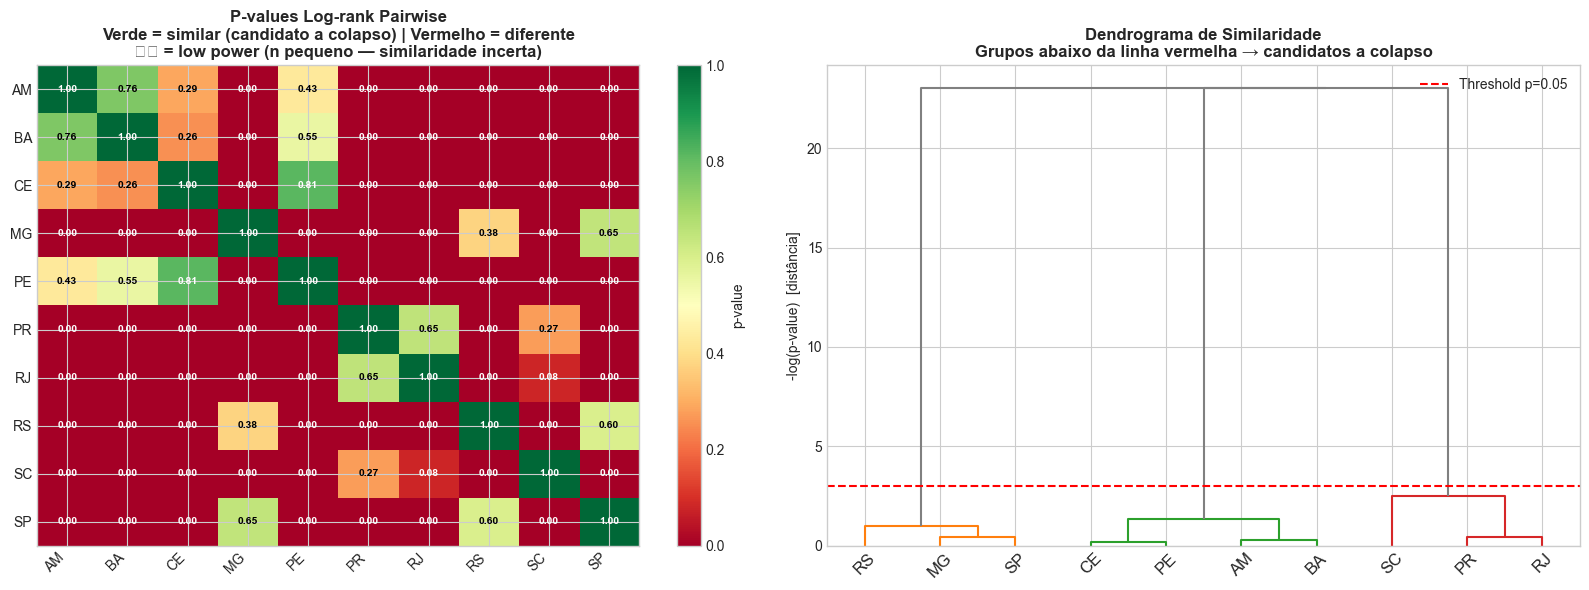

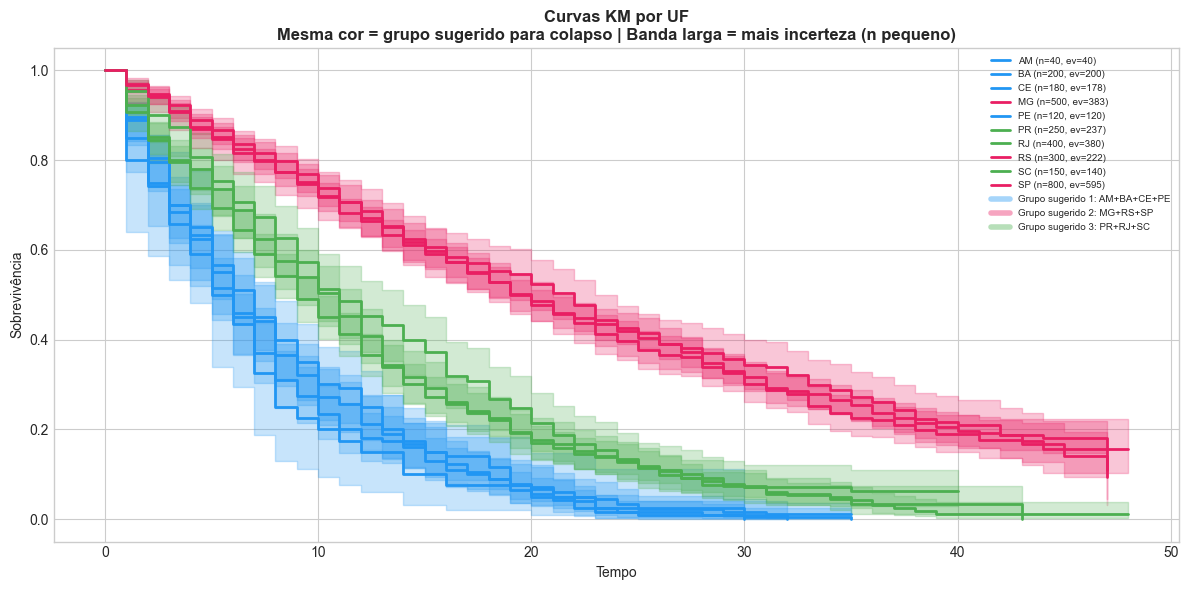


Pairwise completo (ordenado por p-value):
level_a level_b  n_a  n_b  events_a  events_b   pvalue  similar  low_power
     CE      PE  180  120       178       120 0.814715     True      False
     AM      BA   40  200        40       200 0.759791     True      False
     PR      RJ  250  400       237       380 0.651154     True      False
     MG      SP  500  800       383       595 0.647055     True      False
     RS      SP  300  800       222       595 0.597023     True      False
     BA      PE  200  120       200       120 0.554642     True      False
     AM      PE   40  120        40       120 0.433191     True      False
     MG      RS  500  300       383       222 0.377705     True      False
     AM      CE   40  180        40       178 0.292608     True      False
     PR      SC  250  150       237       140 0.273512     True      False
     BA      CE  200  180       200       178 0.256546     True      False
     RJ      SC  400  150       380       140 0.081435   

In [4]:
result = collapsing_report(
    df,
    category_col='uf',
    time_col='time',
    event_col='event',
    pvalue_threshold=0.05,
    min_events=10
)

print('\nPairwise completo (ordenado por p-value):')
print(result['pairwise'][['level_a','level_b','n_a','n_b',
                           'events_a','events_b','pvalue',
                           'similar','low_power']].to_string(index=False))

## 4. Testes Unitários

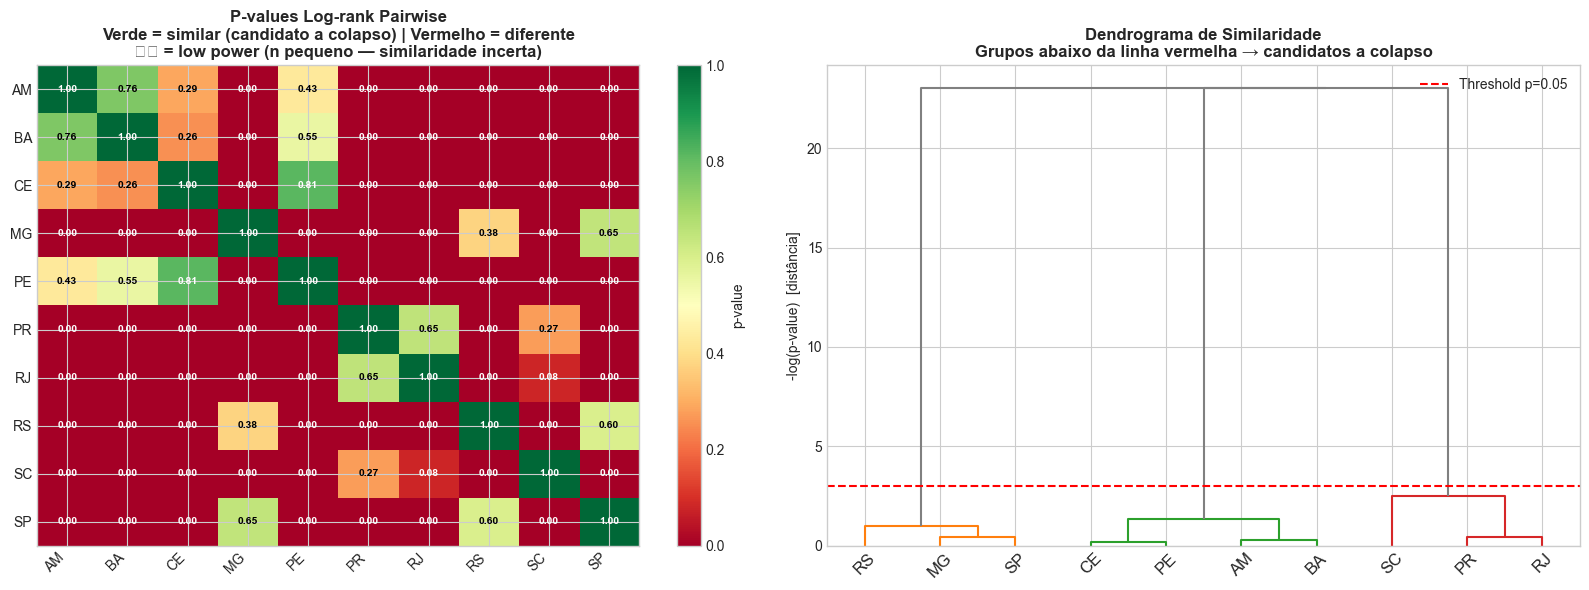

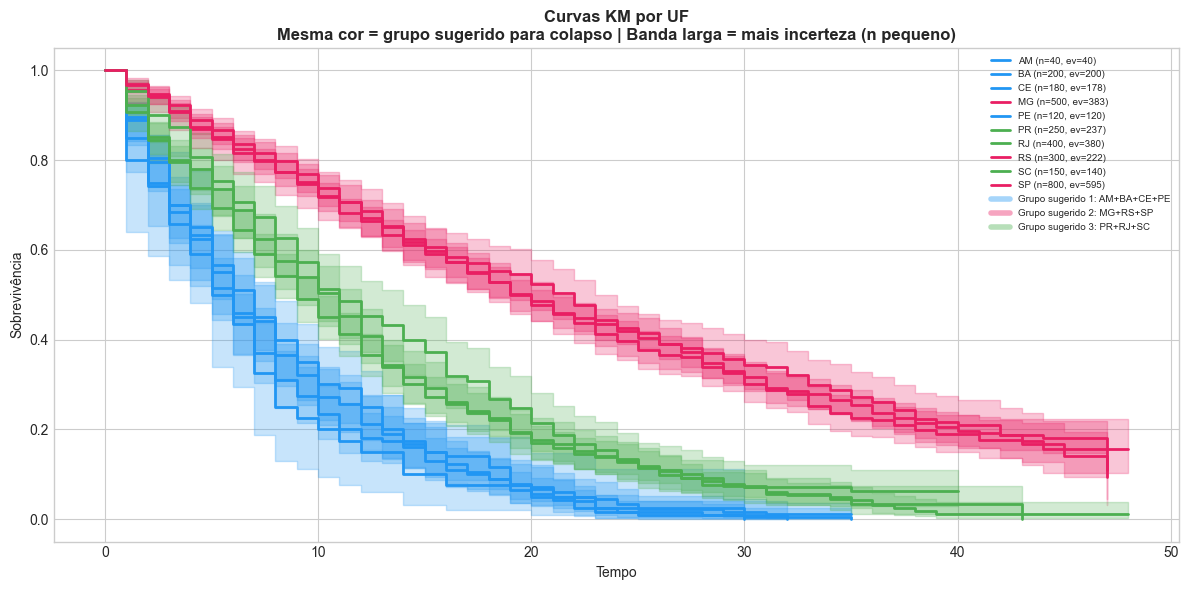

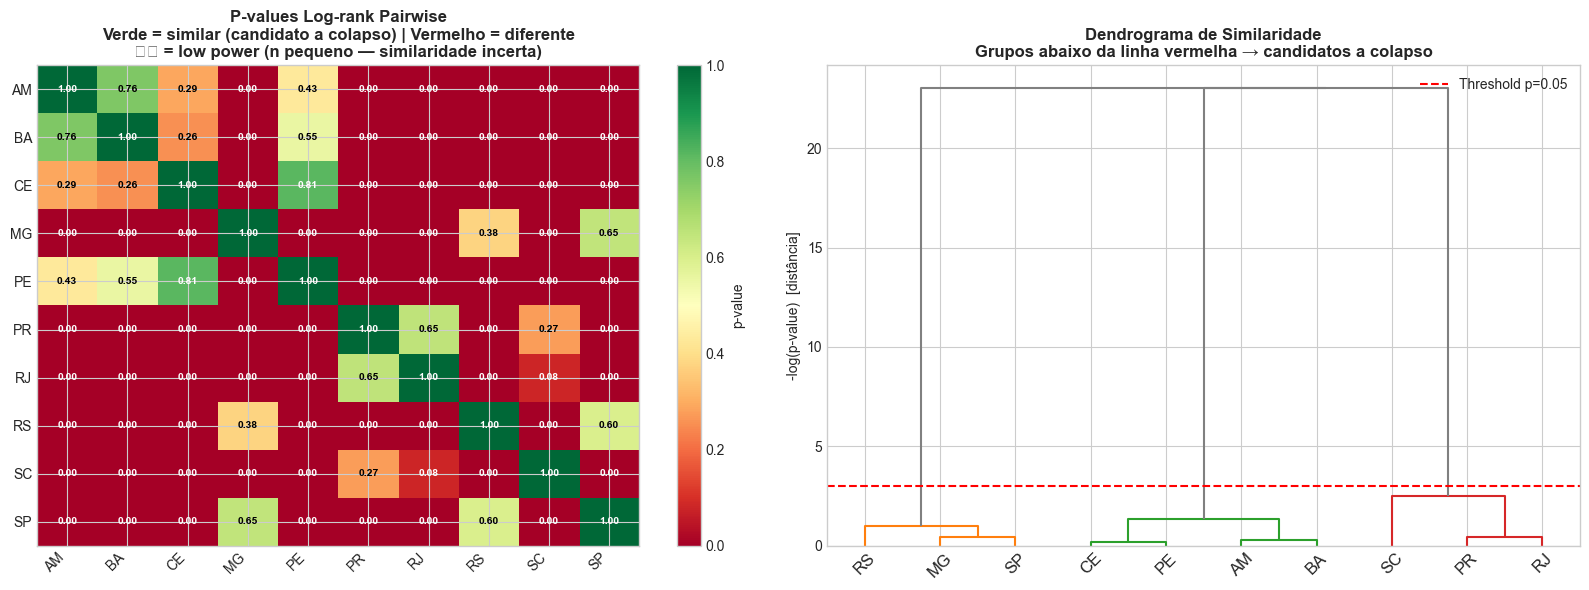

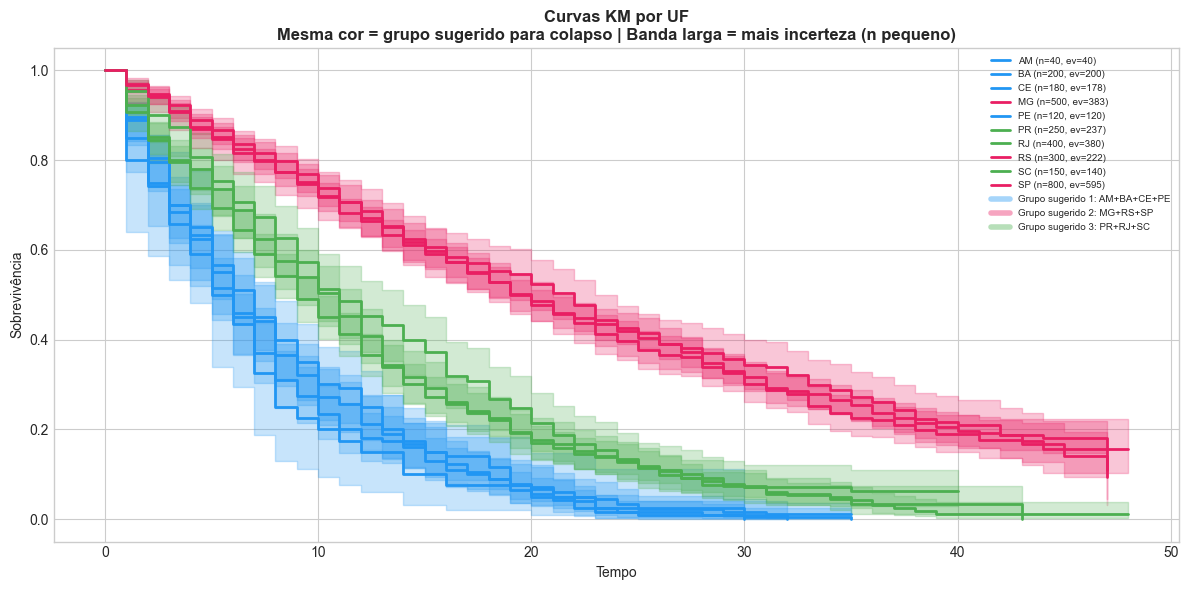

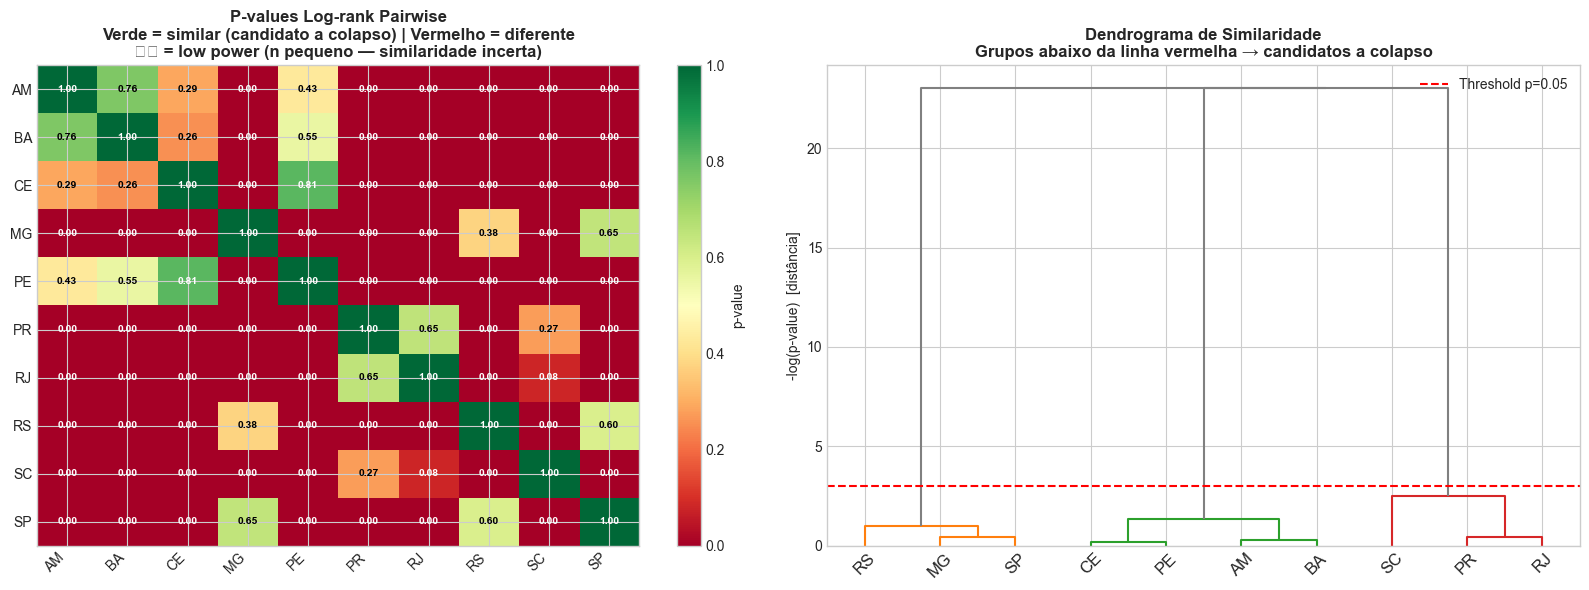

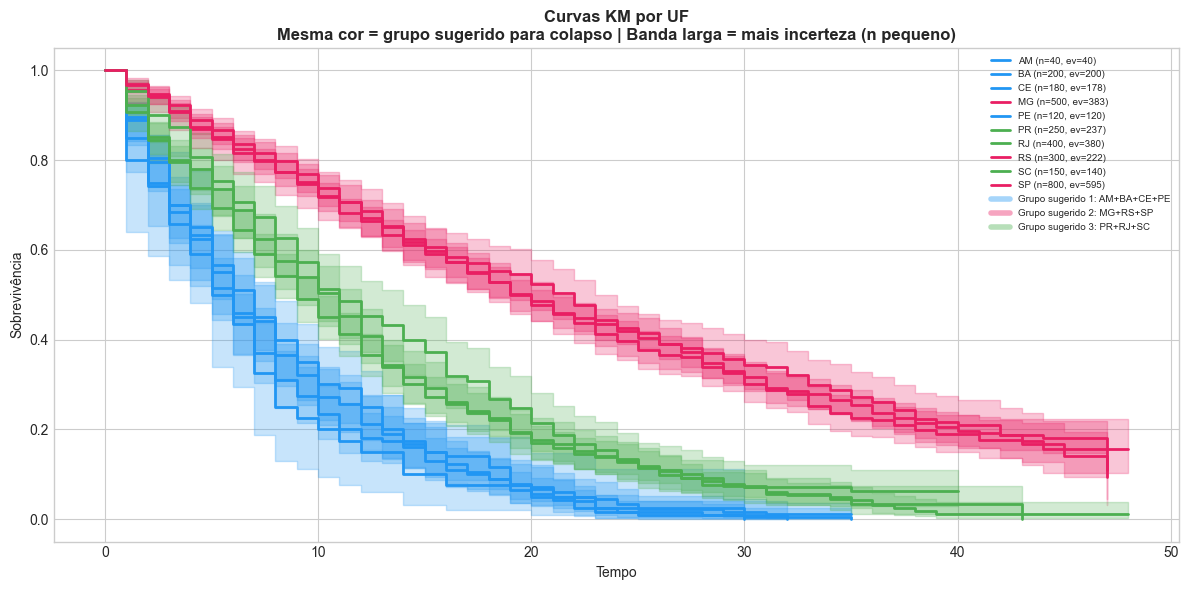

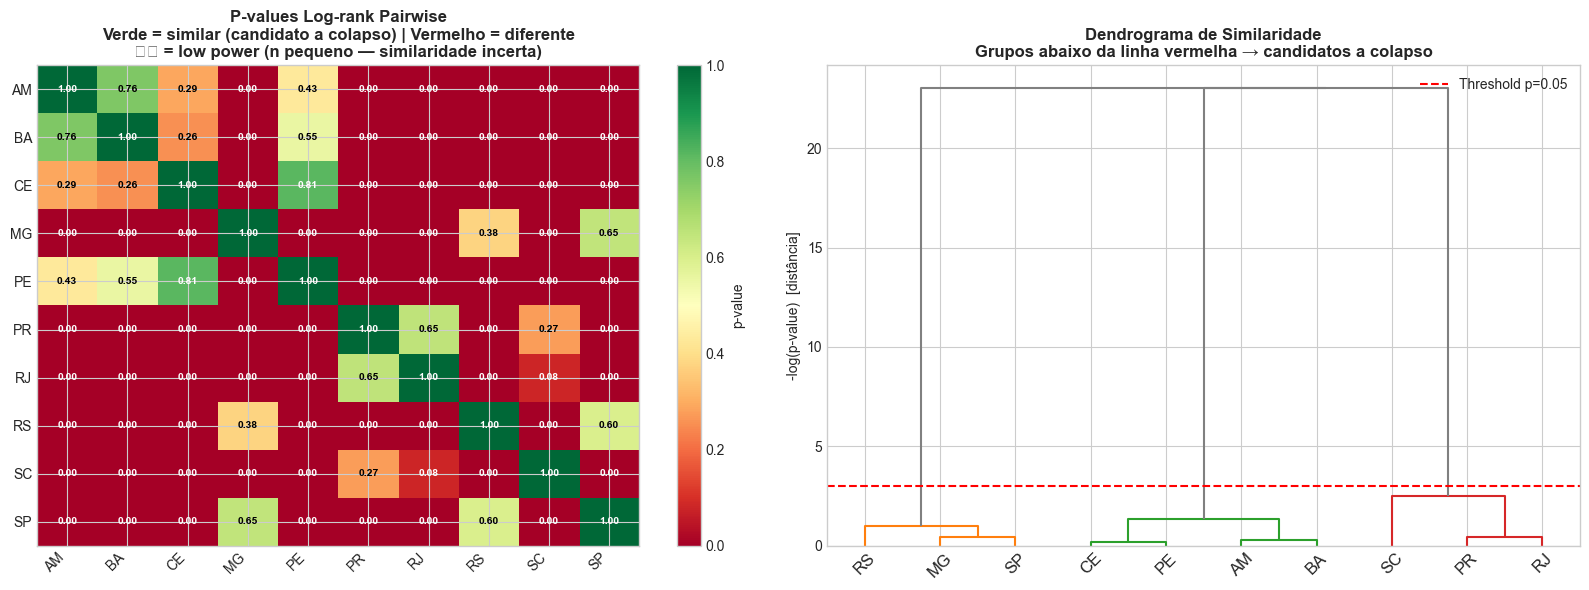

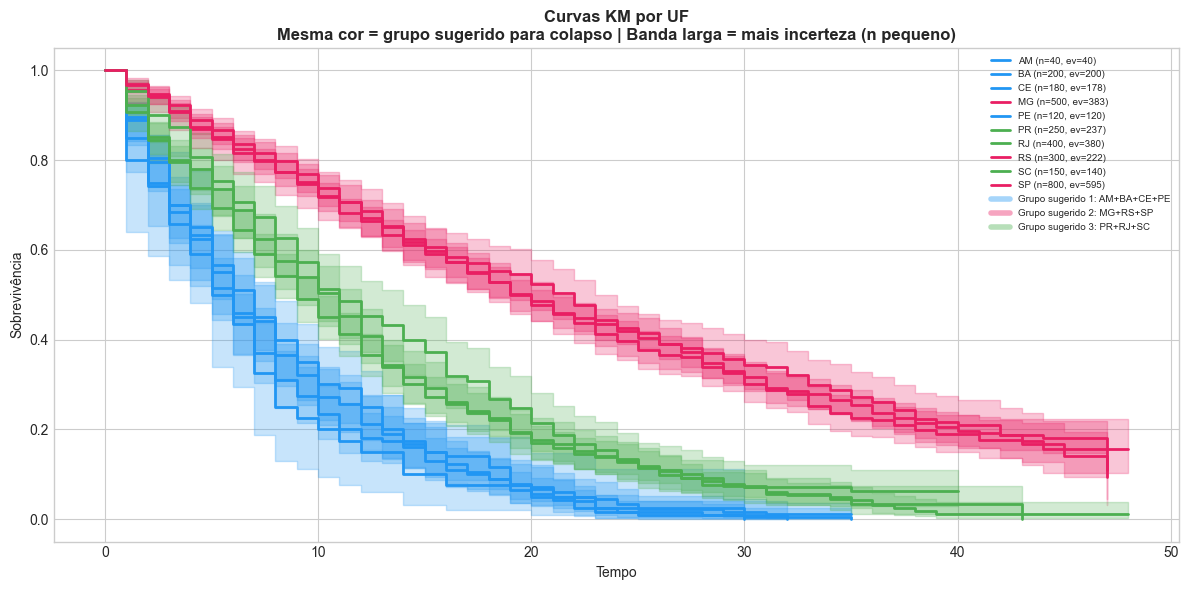

test_different_groups_low_pvalue (__main__.TestPairwiseLogrank)
Pares entre grupos diferentes devem ter p-value baixo ... ok
test_low_power_flag_for_small_uf (__main__.TestPairwiseLogrank)
AM tem apenas 40 contratos → pares envolvendo AM devem ser ... FAIL
test_no_low_power_for_large_ufs (__main__.TestPairwiseLogrank)
SP (n=800) e MG (n=500) têm muitos eventos → ... ok
test_number_of_pairs (__main__.TestPairwiseLogrank)
Deve retornar C(n_levels, 2) pares. ... ok
test_output_columns (__main__.TestPairwiseLogrank)
Saída deve ter todas as colunas esperadas. ... ok
test_pvalue_range (__main__.TestPairwiseLogrank)
P-values devem estar entre 0 e 1. ... ok
test_same_group_high_pvalue (__main__.TestPairwiseLogrank)
Pares dentro do mesmo grupo verdadeiro devem ter p-value alto ... ok
test_similar_flag_consistent_with_pvalue (__main__.TestPairwiseLogrank)
Flag 'similar' deve ser consistente com pvalue > 0.05. ... ok
test_all_levels_covered (__main__.TestSuggestCollapsing)
Todos os níveis devem a

<unittest.runner.TextTestResult run=17 errors=0 failures=1>

In [5]:
class TestPairwiseLogrank(unittest.TestCase):
    """Testes para pairwise_logrank."""

    @classmethod
    def setUpClass(cls):
        cls.df = make_uf_dataset(TRUE_GROUPS, UF_SIZES, random_state=42)

    def test_number_of_pairs(self):
        """Deve retornar C(n_levels, 2) pares."""
        n_levels = self.df['uf'].nunique()
        result   = pairwise_logrank(self.df, 'uf', 'time', 'event')
        expected = n_levels * (n_levels - 1) // 2
        self.assertEqual(len(result), expected)

    def test_pvalue_range(self):
        """P-values devem estar entre 0 e 1."""
        result = pairwise_logrank(self.df, 'uf', 'time', 'event')
        valid  = result['pvalue'].dropna()
        self.assertTrue((valid >= 0).all())
        self.assertTrue((valid <= 1).all())

    def test_same_group_high_pvalue(self):
        """
        Pares dentro do mesmo grupo verdadeiro devem ter p-value alto
        (curvas similares → não rejeita H₀).
        """
        result = pairwise_logrank(self.df, 'uf', 'time', 'event')

        # Pares dentro do grupo baixo_risco (SP, MG, RS) — bem amostrados
        intra_baixo = result[
            result['level_a'].isin(['SP','MG','RS']) &
            result['level_b'].isin(['SP','MG','RS'])
        ]
        # Todos devem ter p > 0.05 (não rejeitar similaridade)
        self.assertTrue(
            (intra_baixo['pvalue'] > 0.05).all(),
            msg=f'Pares intra-grupo baixo risco:\n{intra_baixo[["level_a","level_b","pvalue"]]}'
        )

    def test_different_groups_low_pvalue(self):
        """
        Pares entre grupos diferentes devem ter p-value baixo
        (curvas diferentes → rejeita H₀).
        Foca em pares bem amostrados para evitar low_power.
        """
        result = pairwise_logrank(self.df, 'uf', 'time', 'event')

        # SP (baixo) vs BA (alto) — ambos bem amostrados
        pair = result[
            ((result['level_a'] == 'SP') & (result['level_b'] == 'BA')) |
            ((result['level_a'] == 'BA') & (result['level_b'] == 'SP'))
        ]
        self.assertFalse(pair.empty)
        self.assertTrue(
            (pair['pvalue'] < 0.05).all(),
            msg=f'SP vs BA deveria ter p < 0.05: {pair[["pvalue"]].values}'
        )

    def test_low_power_flag_for_small_uf(self):
        """
        AM tem apenas 40 contratos → pares envolvendo AM devem ser
        flagged como low_power.
        """
        result = pairwise_logrank(self.df, 'uf', 'time', 'event',
                                  min_events=10)
        am_pairs = result[
            (result['level_a'] == 'AM') | (result['level_b'] == 'AM')
        ]
        self.assertFalse(am_pairs.empty)
        self.assertTrue(
            am_pairs['low_power'].all(),
            msg='AM deveria ter low_power=True em todos os pares'
        )

    def test_no_low_power_for_large_ufs(self):
        """
        SP (n=800) e MG (n=500) têm muitos eventos →
        par SP×MG não deve ser low_power.
        """
        result = pairwise_logrank(self.df, 'uf', 'time', 'event')
        pair = result[
            ((result['level_a'] == 'SP') & (result['level_b'] == 'MG')) |
            ((result['level_a'] == 'MG') & (result['level_b'] == 'SP'))
        ]
        self.assertFalse(pair.empty)
        self.assertFalse(
            pair['low_power'].values[0],
            msg='SP × MG não deve ser low_power'
        )

    def test_output_columns(self):
        """Saída deve ter todas as colunas esperadas."""
        result = pairwise_logrank(self.df, 'uf', 'time', 'event')
        expected_cols = ['level_a','level_b','n_a','n_b',
                         'events_a','events_b','logrank_stat',
                         'pvalue','similar','low_power','interpretation']
        for col in expected_cols:
            self.assertIn(col, result.columns)

    def test_similar_flag_consistent_with_pvalue(self):
        """Flag 'similar' deve ser consistente com pvalue > 0.05."""
        result = pairwise_logrank(self.df, 'uf', 'time', 'event')
        valid  = result.dropna(subset=['pvalue'])
        expected_similar = valid['pvalue'] > 0.05
        pd.testing.assert_series_equal(
            valid['similar'].reset_index(drop=True),
            expected_similar.reset_index(drop=True),
            check_names=False
        )


class TestSuggestCollapsing(unittest.TestCase):
    """Testes para suggest_collapsing."""

    @classmethod
    def setUpClass(cls):
        df       = make_uf_dataset(TRUE_GROUPS, UF_SIZES, random_state=42)
        cls.pair = pairwise_logrank(df, 'uf', 'time', 'event')

    def test_returns_list_of_lists(self):
        """Saída deve ser lista de listas."""
        result = suggest_collapsing(self.pair)
        self.assertIsInstance(result, list)
        for group in result:
            self.assertIsInstance(group, list)

    def test_all_levels_covered(self):
        """Todos os níveis devem aparecer em exatamente um grupo."""
        result  = suggest_collapsing(self.pair)
        all_in  = [lv for group in result for lv in group]
        all_levels = set(self.pair['level_a']) | set(self.pair['level_b'])
        self.assertEqual(set(all_in), all_levels)
        # Sem duplicatas
        self.assertEqual(len(all_in), len(set(all_in)))

    def test_n_groups_matches_true_structure(self):
        """
        Com os dados artificiais, deve sugerir exatamente 3 grupos
        (baixo, médio, alto risco) — excluindo AM por low_power.
        """
        result = suggest_collapsing(self.pair, ignore_low_power=False)
        # AM fica sozinho (low_power → não é colapsado com segurança)
        # então esperamos 3 grupos genuínos + AM isolado = 4 grupos
        self.assertGreaterEqual(len(result), 3)

    def test_baixo_risco_same_group(self):
        """
        SP, MG, RS (baixo risco) devem ser sugeridos no mesmo grupo.
        """
        result = suggest_collapsing(self.pair)
        found = False
        for group in result:
            if 'SP' in group and 'MG' in group and 'RS' in group:
                found = True
                break
        self.assertTrue(
            found,
            msg=f'SP, MG, RS deveriam estar no mesmo grupo. Grupos: {result}'
        )

    def test_sp_and_ba_different_groups(self):
        """
        SP (baixo risco) e BA (alto risco) devem estar em grupos diferentes.
        """
        result = suggest_collapsing(self.pair)
        for group in result:
            self.assertFalse(
                ('SP' in group and 'BA' in group),
                msg='SP e BA não deveriam estar no mesmo grupo'
            )


class TestCollapsingReport(unittest.TestCase):
    """Testes de integração para collapsing_report."""

    @classmethod
    def setUpClass(cls):
        cls.df = make_uf_dataset(TRUE_GROUPS, UF_SIZES, random_state=42)

    def test_output_keys(self):
        """Saída deve ter as chaves esperadas."""
        result = collapsing_report(
            self.df, 'uf', 'time', 'event', verbose=False
        )
        for key in ['pairwise', 'suggested_groups', 'collapse_map']:
            self.assertIn(key, result)

    def test_collapse_map_covers_all_levels(self):
        """collapse_map deve mapear todos os níveis."""
        result = collapsing_report(
            self.df, 'uf', 'time', 'event', verbose=False
        )
        all_levels = set(self.df['uf'].unique())
        self.assertEqual(set(result['collapse_map'].keys()), all_levels)

    def test_collapse_map_groups_baixo_risco(self):
        """
        SP, MG, RS devem ter o mesmo valor no collapse_map
        (mesmo rótulo de grupo).
        """
        result = collapsing_report(
            self.df, 'uf', 'time', 'event', verbose=False
        )
        cmap = result['collapse_map']
        self.assertEqual(
            cmap['SP'], cmap['MG'],
            msg=f'SP e MG deveriam ter o mesmo grupo. SP={cmap["SP"]}, MG={cmap["MG"]}'
        )
        self.assertEqual(
            cmap['MG'], cmap['RS'],
            msg=f'MG e RS deveriam ter o mesmo grupo. MG={cmap["MG"]}, RS={cmap["RS"]}'
        )

    def test_collapse_map_separates_extremes(self):
        """
        SP (baixo) e BA (alto) devem ter grupos diferentes no collapse_map.
        """
        result = collapsing_report(
            self.df, 'uf', 'time', 'event', verbose=False
        )
        cmap = result['collapse_map']
        self.assertNotEqual(
            cmap['SP'], cmap['BA'],
            msg='SP e BA não deveriam estar no mesmo grupo'
        )


# ── Runner ────────────────────────────────────────────────────────────────────
def run_tests(verbosity: int = 2):
    suite = unittest.TestSuite()
    for cls in [
        TestPairwiseLogrank,
        TestSuggestCollapsing,
        TestCollapsingReport,
    ]:
        suite.addTests(unittest.TestLoader().loadTestsFromTestCase(cls))

    buf    = io.StringIO()
    runner = unittest.TextTestRunner(stream=buf, verbosity=verbosity)
    result = runner.run(suite)
    print(buf.getvalue())

    total  = result.testsRun
    failed = len(result.failures) + len(result.errors)
    print('═' * 55)
    print(f'  Total: {total} | ✅ Passou: {total-failed} | ❌ Falhou: {failed}')
    print('═' * 55)
    return result


run_tests()

## Pocket

In [6]:
def collapse_categorical_survival(
    df: pd.DataFrame,
    category_col: str,
    time_col: str,
    event_col: str,
    n_groups: Optional[int] = None,
    figsize: Tuple[int, int] = (14, 5),
) -> Dict:
    """
    Identifica quais níveis de uma categórica colapsar em modelos de survival.

    Substitui p-value por distância de efeito entre curvas KM:
      dist(A, B) = integral |KM_A(t) - KM_B(t)| dt  (área entre curvas)

    Invariante ao tamanho amostral — funciona em big data.
    Corte automático pelo maior gap no dendrograma (método do cotovelo).

    Parameters
    ----------
    df            : DataFrame
    category_col  : coluna categórica (ex: 'uf')
    time_col      : coluna de tempo
    event_col     : coluna de evento binário
    n_groups      : número de grupos desejado (None = automático pelo gap)
    figsize       : tamanho da figura

    Returns
    -------
    dict com:
      'collapse_map'     : dict nível → grupo  (use para transformar a coluna)
      'suggested_groups' : lista de listas com os grupos
      'n_groups'         : número de grupos sugerido
      'distance_matrix'  : DataFrame com distâncias entre todos os pares
    """
    from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
    from scipy.spatial.distance   import squareform
    from lifelines                import KaplanMeierFitter

    levels = sorted(df[category_col].dropna().unique())
    n      = len(levels)
    idx    = {lv: i for i, lv in enumerate(levels)}

    # ── 1. KM por nível ───────────────────────────────────────────────────────
    t_max   = int(df[time_col].max())
    times   = np.arange(1, t_max + 1)
    km_curves = {}

    for lv in levels:
        mask = df[category_col] == lv
        kmf  = KaplanMeierFitter()
        kmf.fit(df.loc[mask, time_col], event_observed=df.loc[mask, event_col])
        km_curves[lv] = kmf.survival_function_at_times(times).values

    # ── 2. Distância = área entre curvas (efeito, não p-value) ────────────────
    dist_matrix = np.zeros((n, n))
    for lv_a, lv_b in combinations(levels, 2):
        area = np.trapz(np.abs(km_curves[lv_a] - km_curves[lv_b]), times)
        # Normaliza pelo tempo máximo → distância em [0, 1]
        dist_matrix[idx[lv_a], idx[lv_b]] = area / t_max
        dist_matrix[idx[lv_b], idx[lv_a]] = area / t_max

    # ── 3. Clustering hierárquico + corte automático pelo maior gap ───────────
    Z      = linkage(squareform(dist_matrix), method='complete')
    gaps   = np.diff(Z[:, 2])          # diferença entre distâncias de merge
    cut_at = Z[np.argmax(gaps) + 1, 2] # corta logo acima do maior gap

    if n_groups is not None:
        labels = fcluster(Z, t=n_groups, criterion='maxclust')
    else:
        labels = fcluster(Z, t=cut_at, criterion='distance')

    groups: Dict[int, List] = {}
    for lv, g in zip(levels, labels):
        groups.setdefault(int(g), []).append(lv)
    suggested_groups = list(groups.values())
    n_suggested      = len(suggested_groups)

    collapse_map = {}
    for g_idx, group in enumerate(suggested_groups):
        for lv in group:
            collapse_map[lv] = f'grupo_{g_idx + 1}'

    # ── 4. Plot: dendrograma + KM colorido por grupo ──────────────────────────
    color_palette = ['#2196F3','#E91E63','#4CAF50','#FF9800',
                     '#9C27B0','#00BCD4','#FF5722','#607D8B']

    level_colors = {
        lv: color_palette[g_idx % len(color_palette)]
        for g_idx, group in enumerate(suggested_groups)
        for lv in group
    }

    fig, axes = plt.subplots(1, 2, figsize=figsize)

    # Dendrograma
    def _leaf_color(lv):
        return level_colors.get(lv, 'black')

    link_colors = {}
    for i, (a, b, dist, _) in enumerate(Z):
        link_colors[i + n] = 'gray'

    dendrogram(
        Z, labels=levels, ax=axes[0],
        color_threshold=cut_at,
        above_threshold_color='#AAAAAA',
        leaf_rotation=45
    )
    axes[0].axhline(
        cut_at, color='red', linestyle='--', linewidth=1.8,
        label=f'Corte automático → {n_suggested} grupos'
    )
    axes[0].set_title(
        'Onde colapsar?\nGrupos abaixo da linha = mesmo nível de risco',
        fontweight='bold'
    )
    axes[0].set_ylabel('Distância (área entre curvas KM)')
    axes[0].legend(fontsize=9)

    # KM por nível, colorido por grupo sugerido
    for lv in levels:
        mask  = df[category_col] == lv
        n_lv  = mask.sum()
        kmf   = KaplanMeierFitter(label=f'{lv} [{collapse_map[lv]}]')
        kmf.fit(df.loc[mask, time_col], event_observed=df.loc[mask, event_col])
        kmf.plot_survival_function(
            ax=axes[1],
            color=level_colors[lv],
            ci_show=True,
            linewidth=2
        )

    axes[1].set_title(
        'Curvas KM por nível\nMesma cor = mesmo grupo sugerido',
        fontweight='bold'
    )
    axes[1].set_xlabel('Tempo')
    axes[1].set_ylabel('Sobrevivência')
    axes[1].legend(fontsize=7)

    plt.suptitle(
        f'{category_col.upper()} — {n} níveis → {n_suggested} grupos sugeridos',
        fontsize=12, fontweight='bold', y=1.02
    )
    plt.tight_layout()
    plt.show()

    print(f'\nSugestão de colapso ({n} → {n_suggested} grupos):')
    for g_idx, group in enumerate(suggested_groups):
        print(f'  grupo_{g_idx+1}: {sorted(group)}')
    print(f'\nAplique com: df["{category_col}"] = df["{category_col}"].map(collapse_map)')

    return {
        'collapse_map'    : collapse_map,
        'suggested_groups': suggested_groups,
        'n_groups'        : n_suggested,
        'distance_matrix' : pd.DataFrame(dist_matrix, index=levels, columns=levels),
    }

O que mudou e por quê
Distância = área entre curvas KM em vez de p-value. Com 800 contratos em SP e 40 em AM, se as curvas forem quase idênticas a distância é próxima de zero — independente do n. O p-value com n=800 detectaria diferenças de 1%, que para o seu objetivo de saldo não importam.
Corte automático pelo maior gap no dendrograma — o mesmo princípio do cotovelo do k-means. Você olha os saltos entre as distâncias de merge e corta onde o salto é maior. Não precisa escolher o threshold manualmente.
Dois plots, uma resposta — o dendrograma diz onde cortar, as curvas KM confirmam visualmente se o corte faz sentido. Se as curvas da mesma cor estiverem sobrepostas, o colapso é defensável.

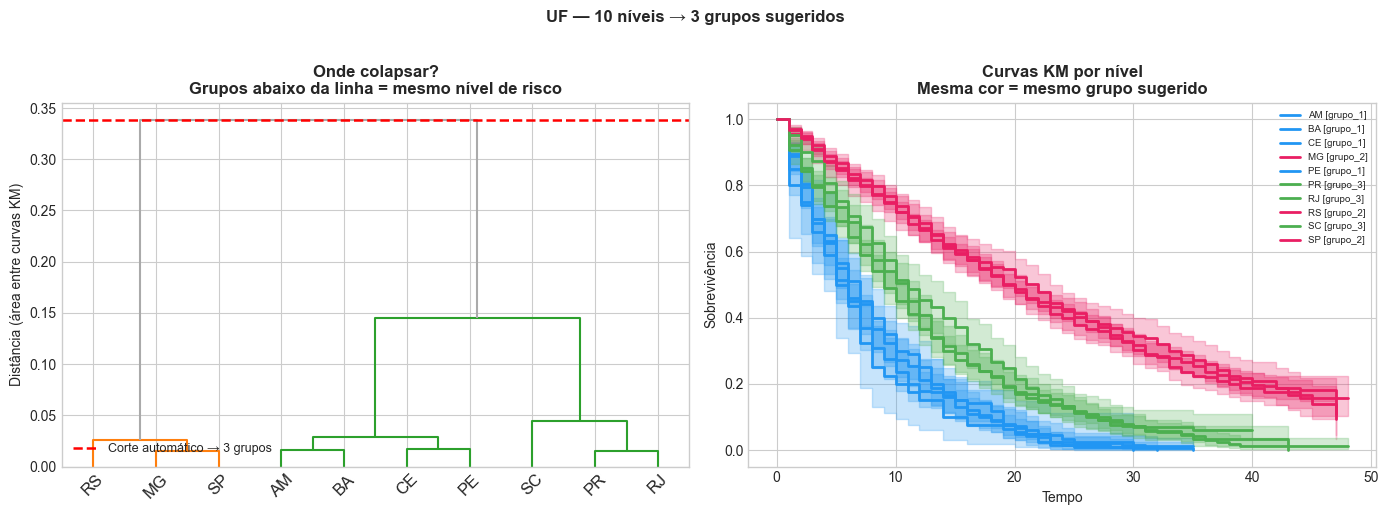


Sugestão de colapso (10 → 3 grupos):
  grupo_1: ['AM', 'BA', 'CE', 'PE']
  grupo_2: ['MG', 'RS', 'SP']
  grupo_3: ['PR', 'RJ', 'SC']

Aplique com: df["uf"] = df["uf"].map(collapse_map)


In [8]:
# result = collapse_categorical_survival(df, 'uf', 'time', 'event')
# df['uf_colapsada'] = df['uf'].map(result['collapse_map'])

# Se quiser forçar um número específico de grupos:
result = collapse_categorical_survival(df, 'uf', 'time', 'event', n_groups=3)

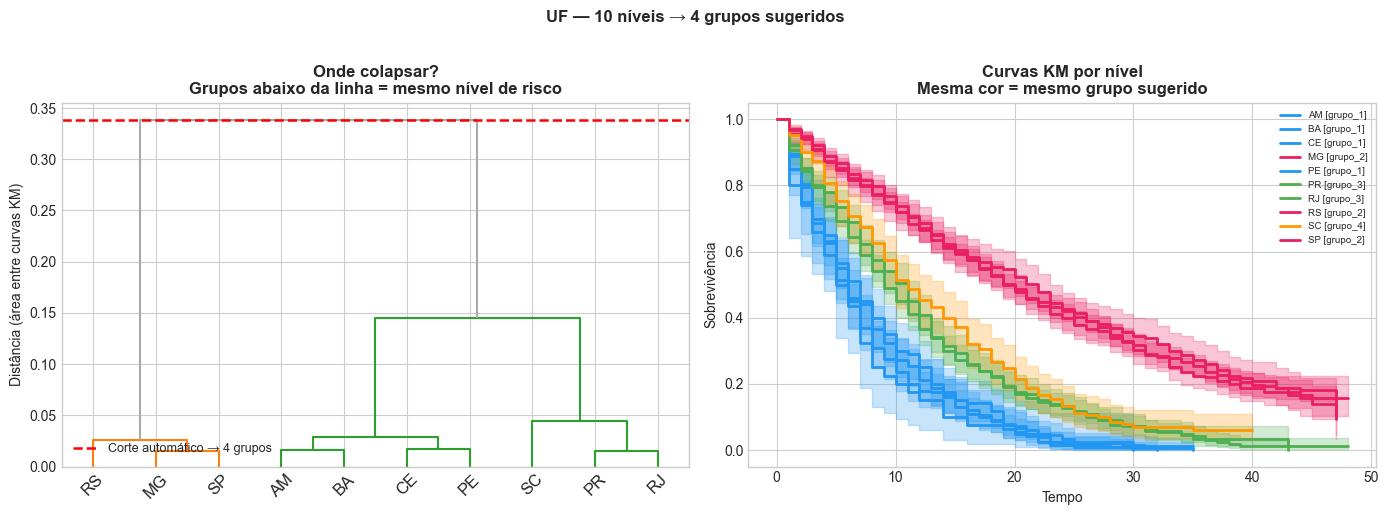


Sugestão de colapso (10 → 4 grupos):
  grupo_1: ['AM', 'BA', 'CE', 'PE']
  grupo_2: ['MG', 'RS', 'SP']
  grupo_3: ['PR', 'RJ']
  grupo_4: ['SC']

Aplique com: df["uf"] = df["uf"].map(collapse_map)


In [9]:
result = collapse_categorical_survival(df, 'uf', 'time', 'event', n_groups=4)

[Silhouette por n]  [Dendrograma]  [KM por nível]
  barra verde =       linha vermelha   mesma cor =
  recomendado         = onde cortar    mesmo grupo

Vamos automatizar a busca de coisas boas. 

In [ ]:
# Busca automática — usa 20% do dataset, testa de 2 a 8 grupos
result = collapse_categorical_survival(
    df, 'uf', 'time', 'event',
    sample_pct=0.20,
    max_groups=8
)

# Forçar n fixo (pula a busca, silhouette_scores fica vazio)
result = collapse_categorical_survival(
    df, 'uf', 'time', 'event',
    n_groups=3, sample_pct=0.20
)

# Aplicar no dataset completo
df['uf_colapsada'] = df['uf'].map(result['collapse_map'])

NameError: name 'collapse_categorical_survival' is not defined

Sample: 882 linhas (30% de 2,940)

Silhouette por n_groups:
   n=2: 0.7546 <- melhor
   n=3: 0.6674
   n=4: 0.5812
   n=5: 0.4141
   n=6: 0.3031


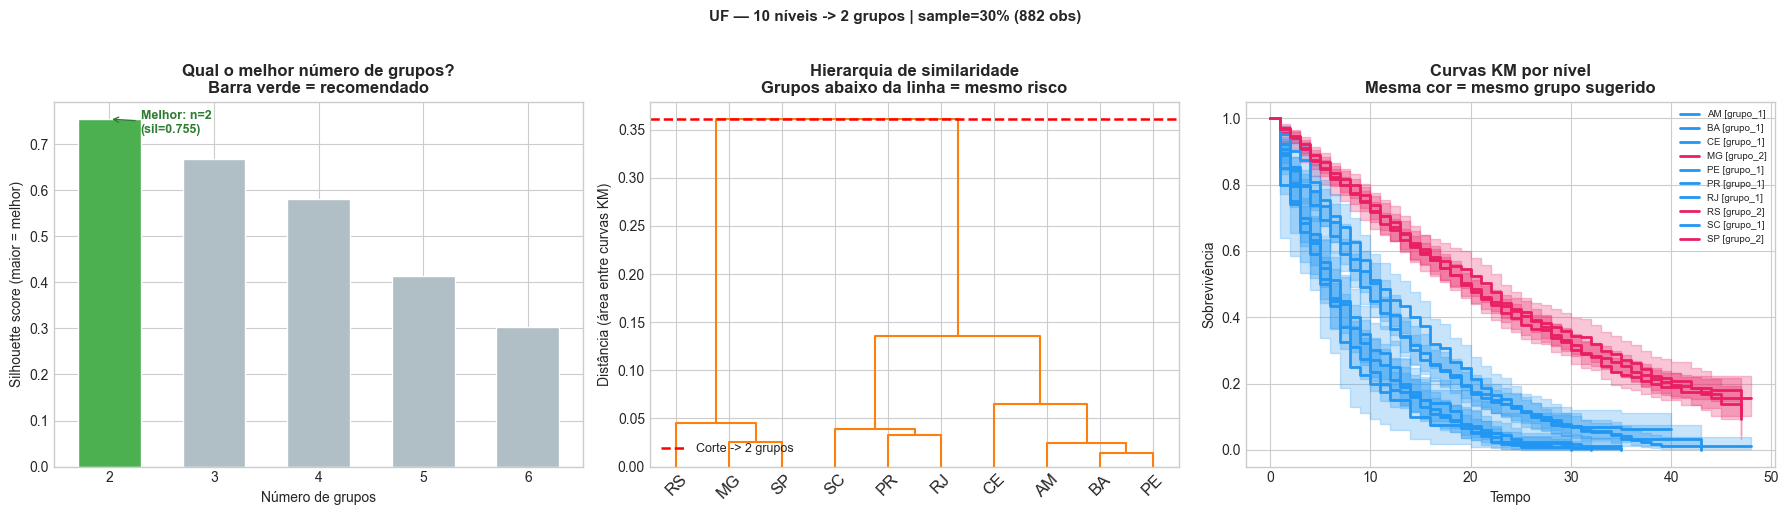


Sugestão de colapso (10 -> 2 grupos):
   grupo_1: ['AM', 'BA', 'CE', 'PE', 'PR', 'RJ', 'SC']
   grupo_2: ['MG', 'RS', 'SP']

Aplique com:
   df["uf"] = df["uf"].map(collapse_map)
Sample: 882 linhas (30% de 2,940)

Silhouette por n_groups:
   n=2: 0.7546 <- melhor
   n=3: 0.6674
   n=4: 0.5812
   n=5: 0.4141
   n=6: 0.3031


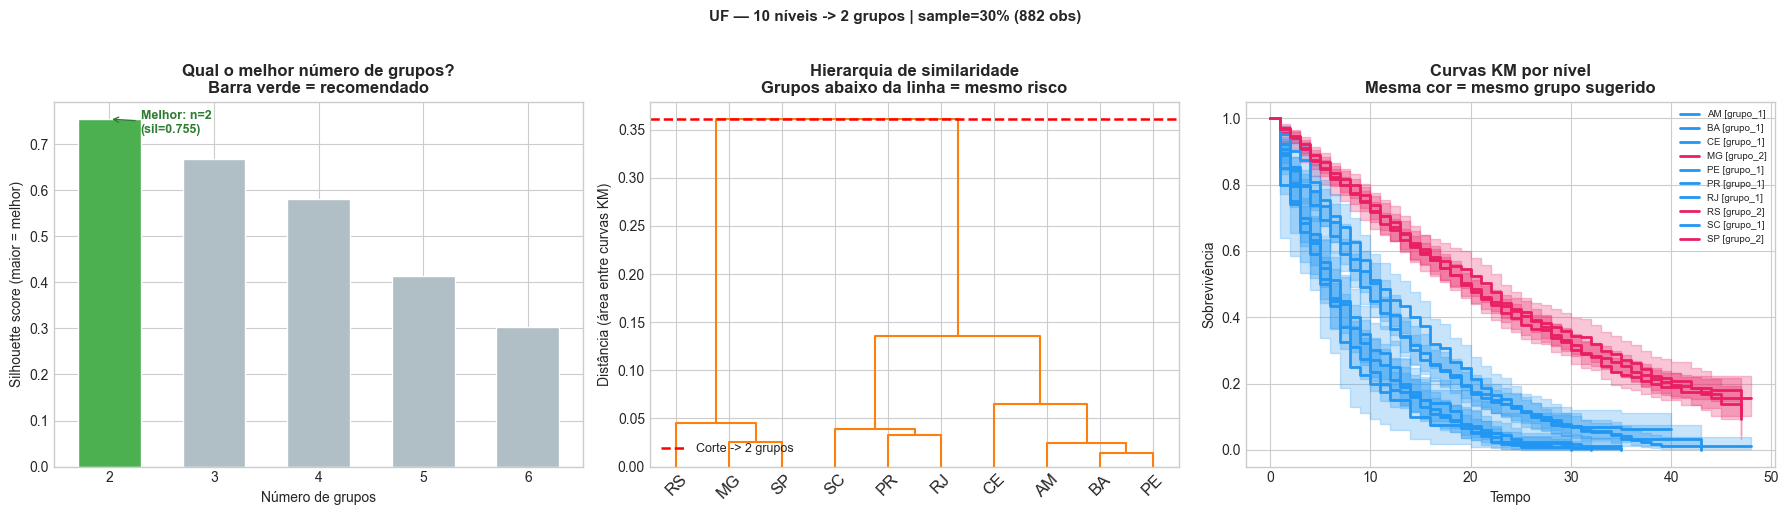


Sugestão de colapso (10 -> 2 grupos):
   grupo_1: ['AM', 'BA', 'CE', 'PE', 'PR', 'RJ', 'SC']
   grupo_2: ['MG', 'RS', 'SP']

Aplique com:
   df["uf"] = df["uf"].map(collapse_map)
Sample: 588 linhas (20% de 2,940)
n_groups fixado em 2 (busca automática desativada)


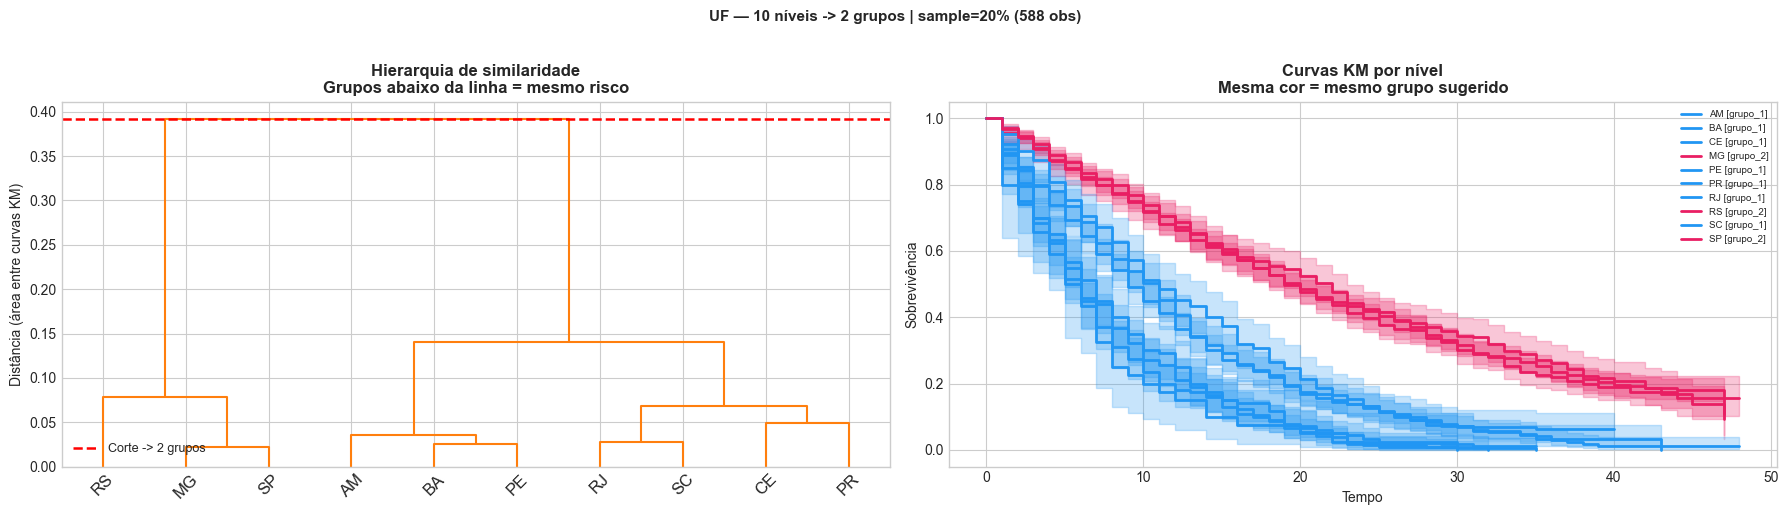


Sugestão de colapso (10 -> 2 grupos):
   grupo_1: ['AM', 'BA', 'CE', 'PE', 'PR', 'RJ', 'SC']
   grupo_2: ['MG', 'RS', 'SP']

Aplique com:
   df["uf"] = df["uf"].map(collapse_map)
Sample: 588 linhas (20% de 2,940)
n_groups fixado em 2 (busca automática desativada)


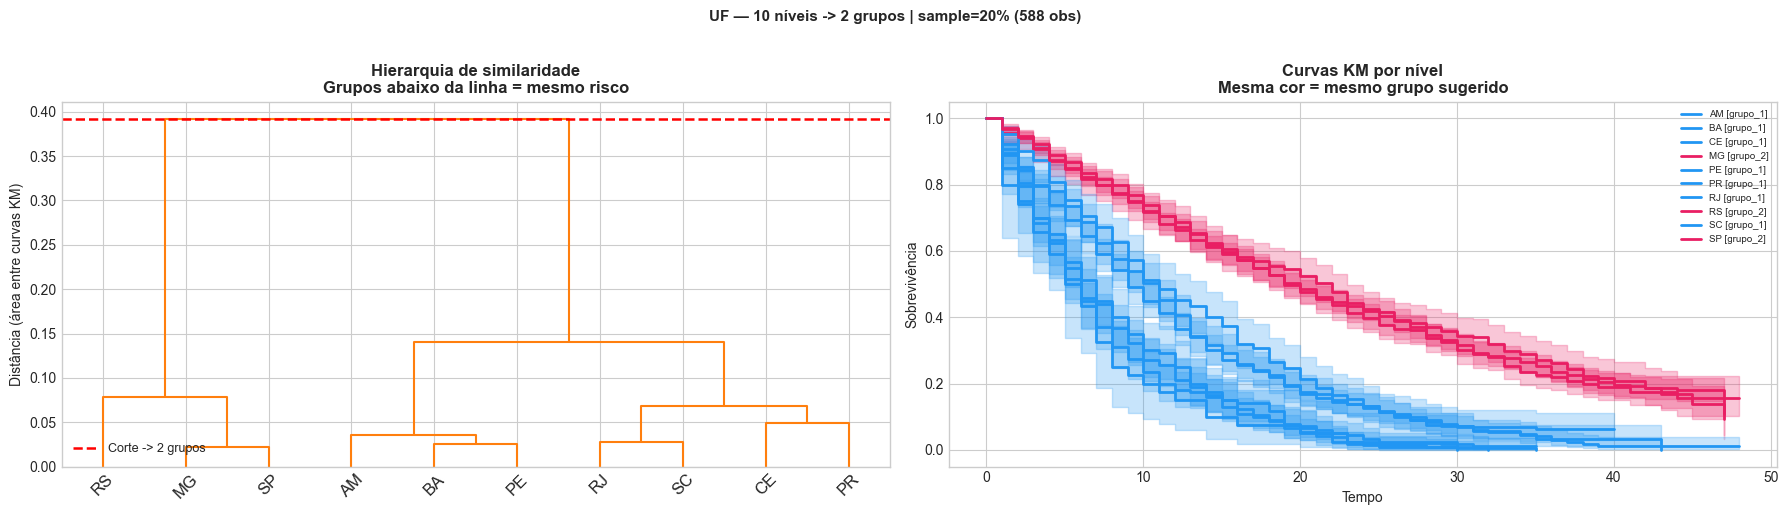


Sugestão de colapso (10 -> 2 grupos):
   grupo_1: ['AM', 'BA', 'CE', 'PE', 'PR', 'RJ', 'SC']
   grupo_2: ['MG', 'RS', 'SP']

Aplique com:
   df["uf"] = df["uf"].map(collapse_map)

Silhouette por n_groups:
   n=2: 0.7790
   n=3: 0.8010 <- melhor
   n=4: 0.6987
   n=5: 0.5025
   n=6: 0.2917


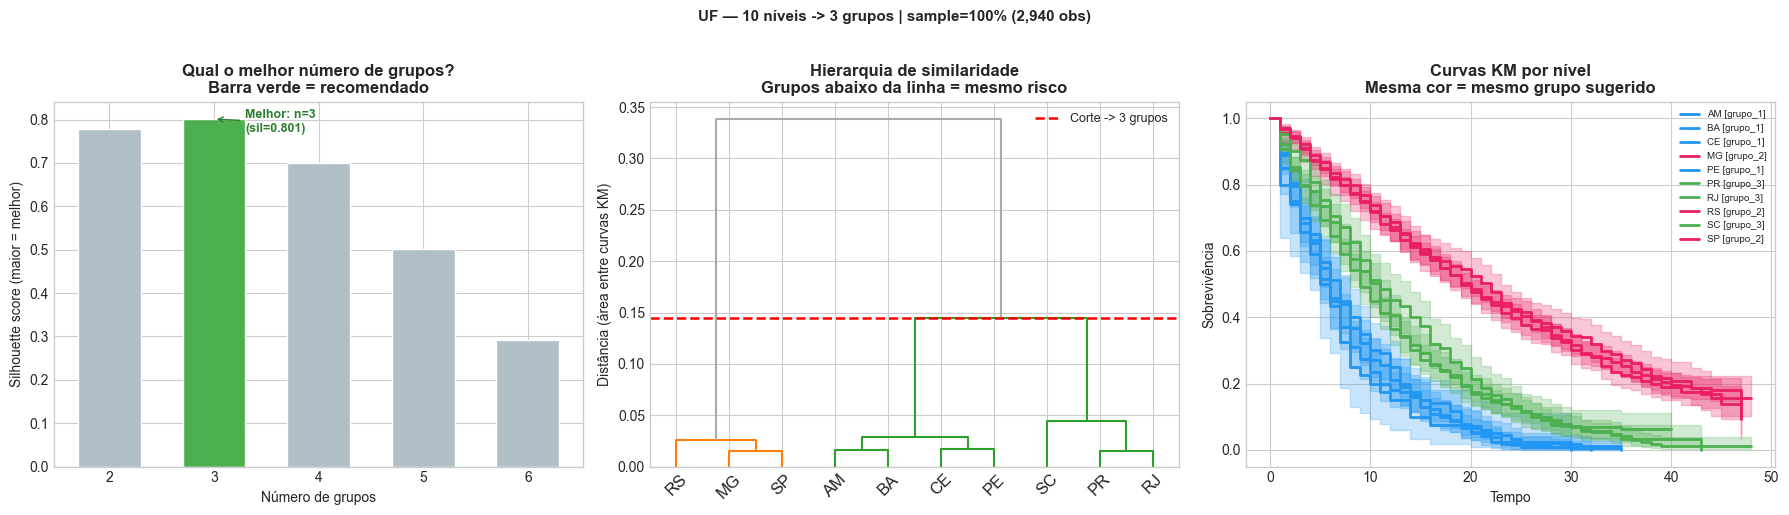


Sugestão de colapso (10 -> 3 grupos):
   grupo_1: ['AM', 'BA', 'CE', 'PE']
   grupo_2: ['MG', 'RS', 'SP']
   grupo_3: ['PR', 'RJ', 'SC']

Aplique com:
   df["uf"] = df["uf"].map(collapse_map)
Sample: 294 linhas (10% de 2,940)

Silhouette por n_groups:
   n=2: 0.7209 <- melhor
   n=3: 0.6361
   n=4: 0.5653


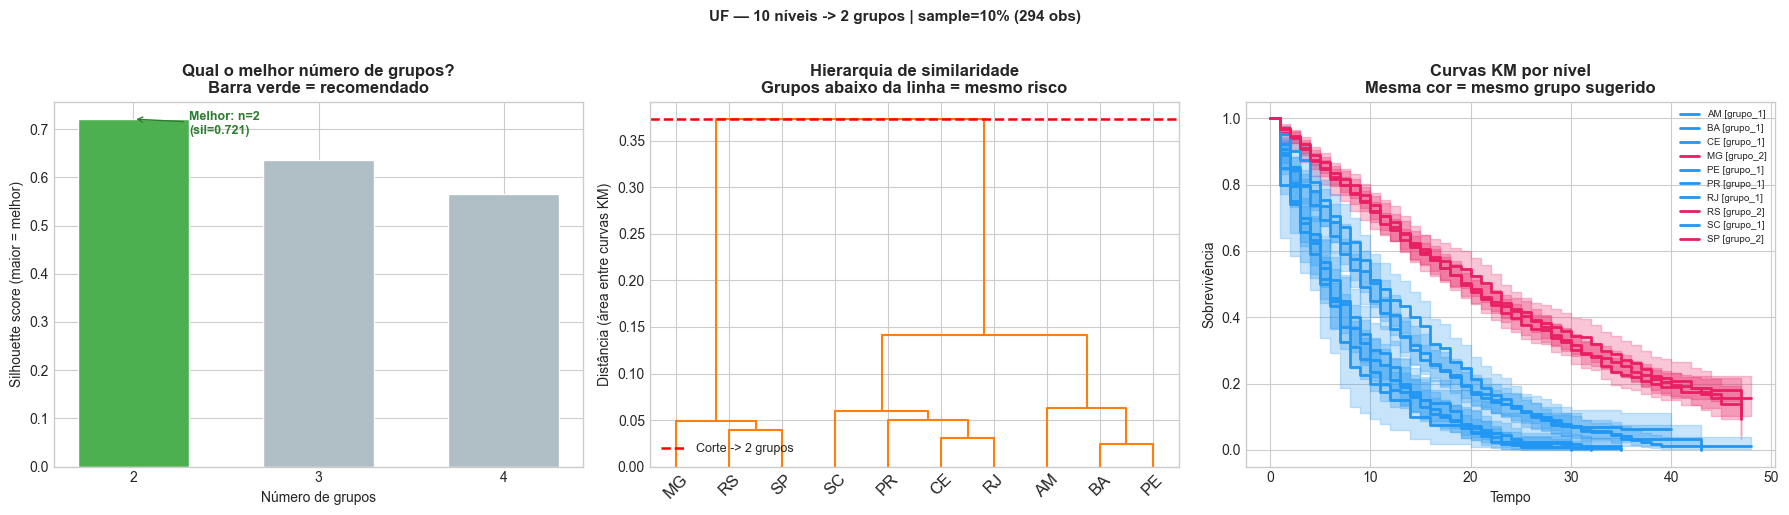


Sugestão de colapso (10 -> 2 grupos):
   grupo_1: ['AM', 'BA', 'CE', 'PE', 'PR', 'RJ', 'SC']
   grupo_2: ['MG', 'RS', 'SP']

Aplique com:
   df["uf"] = df["uf"].map(collapse_map)
test_all_levels_in_exactly_one_group (__main__.TestCollapseCategoricalSurvival) ... ok
test_alto_risco_same_group (__main__.TestCollapseCategoricalSurvival) ... ok
test_baixo_risco_same_group (__main__.TestCollapseCategoricalSurvival) ... ok
test_best_n_is_argmax_silhouette (__main__.TestCollapseCategoricalSurvival) ... ok
test_collapse_map_covers_all_levels (__main__.TestCollapseCategoricalSurvival) ... ok
test_distance_matrix_diagonal_zero (__main__.TestCollapseCategoricalSurvival) ... ok
test_distance_matrix_range (__main__.TestCollapseCategoricalSurvival) ... ok
test_distance_matrix_shape (__main__.TestCollapseCategoricalSurvival) ... ok
test_distance_matrix_symmetric (__main__.TestCollapseCategoricalSurvival) ... ok
test_extremes_different_groups (__main__.TestCollapseCategoricalSurvival) ... ok
test_fin

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import unittest
import io
from itertools  import combinations
from typing     import Dict, List, Optional, Tuple

from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance  import squareform
from sklearn.metrics         import silhouette_score
from lifelines               import KaplanMeierFitter

plt.style.use('seaborn-v0_8-whitegrid')
PALETTE = ['#2196F3','#E91E63','#4CAF50','#FF9800',
           '#9C27B0','#00BCD4','#FF5722','#607D8B']
np.random.seed(42)


def collapse_categorical_survival(
    df: pd.DataFrame,
    category_col: str,
    time_col: str,
    event_col: str,
    sample_pct: float = 1.0,
    max_groups: Optional[int] = None,
    n_groups: Optional[int] = None,
    random_state: int = 42,
    figsize: Tuple[int, int] = (18, 5),
) -> Dict:
    """
    Identifica onde colapsar os níveis de uma categórica em survival.

    Distância entre níveis = área integrada entre curvas KM (invariante ao n).
    Seleção do número ótimo de grupos = silhouette score sobre a matriz de distâncias.

    Suporta amostragem para datasets grandes: as curvas KM são estimadas
    no sample, mas o colapso é aplicado no dataset completo.

    Parameters
    ----------
    df            : DataFrame completo
    category_col  : coluna categórica (ex: 'uf')
    time_col      : coluna de tempo
    event_col     : coluna de evento binário
    sample_pct    : fração do dataset usada para estimar as curvas KM
                    (ex: 0.20 = 20% — suficiente para estabilizar a curva)
                    Estratificado por category_col para preservar todos os níveis.
    max_groups    : número máximo de grupos a testar (None = n_levels - 1)
    n_groups      : se informado, pula a busca e usa esse número diretamente
    random_state  : semente para o sample
    figsize       : tamanho da figura

    Returns
    -------
    dict com:
      'collapse_map'     : dict nível -> 'grupo_N'  (aplique no df completo)
      'suggested_groups' : lista de listas com os grupos
      'best_n_groups'    : número de grupos escolhido
      'silhouette_scores': dict n_groups -> silhouette score
      'distance_matrix'  : DataFrame com distâncias entre todos os pares
    """
    # 0. Amostragem estratificada
    if sample_pct < 1.0:
        sample = (
            df.groupby(category_col, group_keys=False)
              .apply(lambda g: g.sample(
                  frac=sample_pct,
                  random_state=random_state,
                  replace=len(g) < 10
              ))
        )
        print(f'Sample: {len(sample):,} linhas ({sample_pct:.0%} de {len(df):,})')
    else:
        sample = df

    levels = sorted(sample[category_col].dropna().unique())
    n_lvl  = len(levels)
    idx    = {lv: i for i, lv in enumerate(levels)}
    t_max  = int(sample[time_col].max())
    times  = np.arange(1, t_max + 1)

    # 1. Curvas KM por nível (no sample)
    km_curves = {}
    for lv in levels:
        mask = sample[category_col] == lv
        kmf  = KaplanMeierFitter()
        kmf.fit(sample.loc[mask, time_col],
                event_observed=sample.loc[mask, event_col])
        km_curves[lv] = kmf.survival_function_at_times(times).values

    # 2. Matriz de distância = área entre curvas (efeito, não p-value)
    dist_matrix = np.zeros((n_lvl, n_lvl))
    for lv_a, lv_b in combinations(levels, 2):
        area = float(np.trapz(
            np.abs(km_curves[lv_a] - km_curves[lv_b]), times
        )) / t_max                              # normaliza -> [0, 1]
        dist_matrix[idx[lv_a], idx[lv_b]] = area
        dist_matrix[idx[lv_b], idx[lv_a]] = area

    Z = linkage(squareform(dist_matrix), method='complete')

    # 3. Busca do n_groups ótimo via silhouette
    if n_groups is not None:
        best_n     = n_groups
        sil_scores = {}
        print(f'n_groups fixado em {best_n} (busca automática desativada)')
    else:
        max_g      = max_groups or (n_lvl - 1)
        max_g      = min(max_g, n_lvl - 1)
        sil_scores = {}

        for k in range(2, max_g + 1):
            labels_k = fcluster(Z, t=k, criterion='maxclust')
            if len(np.unique(labels_k)) < 2:
                continue
            sil = silhouette_score(dist_matrix, labels_k, metric='precomputed')
            sil_scores[k] = round(float(sil), 4)

        best_n = max(sil_scores, key=sil_scores.get)
        print(f'\nSilhouette por n_groups:')
        for k, s in sorted(sil_scores.items()):
            marker = ' <- melhor' if k == best_n else ''
            print(f'   n={k}: {s:.4f}{marker}')

    # 4. Agrupamento final
    final_labels   = fcluster(Z, t=best_n, criterion='maxclust')
    groups: Dict   = {}
    for lv, g in zip(levels, final_labels):
        groups.setdefault(int(g), []).append(lv)
    suggested_groups = list(groups.values())

    collapse_map = {
        lv: f'grupo_{g_idx + 1}'
        for g_idx, group in enumerate(suggested_groups)
        for lv in group
    }
    level_colors = {
        lv: PALETTE[g_idx % len(PALETTE)]
        for g_idx, group in enumerate(suggested_groups)
        for lv in group
    }

    # 5. Plots
    n_plots = 3 if sil_scores else 2
    fig, axes = plt.subplots(1, n_plots, figsize=figsize)

    ax_sil, ax_dend, ax_km = (
        (axes[0], axes[1], axes[2]) if sil_scores
        else (None, axes[0], axes[1])
    )

    # Silhouette score por n_groups
    if ax_sil is not None and sil_scores:
        ks = sorted(sil_scores.keys())
        ss = [sil_scores[k] for k in ks]
        bar_colors = [
            '#4CAF50' if k == best_n else '#B0BEC5' for k in ks
        ]
        ax_sil.bar(ks, ss, color=bar_colors, edgecolor='white', width=0.6)
        ax_sil.set_xticks(ks)
        ax_sil.set_xlabel('Número de grupos')
        ax_sil.set_ylabel('Silhouette score (maior = melhor)')
        ax_sil.set_title(
            'Qual o melhor número de grupos?\nBarra verde = recomendado',
            fontweight='bold'
        )
        ax_sil.annotate(
            f'Melhor: n={best_n}\n(sil={sil_scores[best_n]:.3f})',
            xy=(best_n, sil_scores[best_n]),
            xytext=(best_n + 0.3, sil_scores[best_n] - 0.03),
            fontsize=9, color='#2E7D32', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#2E7D32')
        )

    # Dendrograma
    cut_at = float(Z[-(best_n - 1), 2]) + 1e-9
    dendrogram(
        Z, labels=levels, ax=ax_dend,
        color_threshold=cut_at,
        above_threshold_color='#AAAAAA',
        leaf_rotation=45
    )
    ax_dend.axhline(
        cut_at, color='red', linestyle='--',
        linewidth=1.8, label=f'Corte -> {best_n} grupos'
    )
    ax_dend.set_title(
        'Hierarquia de similaridade\nGrupos abaixo da linha = mesmo risco',
        fontweight='bold'
    )
    ax_dend.set_ylabel('Distância (área entre curvas KM)')
    ax_dend.legend(fontsize=9)

    # KM colorido por grupo
    for lv in levels:
        mask = df[category_col] == lv
        kmf  = KaplanMeierFitter(label=f'{lv} [{collapse_map[lv]}]')
        kmf.fit(df.loc[mask, time_col],
                event_observed=df.loc[mask, event_col])
        kmf.plot_survival_function(
            ax=ax_km, color=level_colors[lv],
            ci_show=True, linewidth=2
        )
    ax_km.set_title(
        'Curvas KM por nível\nMesma cor = mesmo grupo sugerido',
        fontweight='bold'
    )
    ax_km.set_xlabel('Tempo')
    ax_km.set_ylabel('Sobrevivência')
    ax_km.legend(fontsize=7)

    plt.suptitle(
        f'{category_col.upper()} — {n_lvl} níveis -> {best_n} grupos '
        f'| sample={sample_pct:.0%} ({len(sample):,} obs)',
        fontsize=11, fontweight='bold', y=1.02
    )
    plt.tight_layout()
    plt.show()

    # 6. Sumário
    print(f'\nSugestão de colapso ({n_lvl} -> {best_n} grupos):')
    for g_idx, group in enumerate(suggested_groups):
        print(f'   grupo_{g_idx+1}: {sorted(group)}')
    print(f'\nAplique com:')
    print(f'   df["{category_col}"] = df["{category_col}"].map(collapse_map)')

    return {
        'collapse_map'     : collapse_map,
        'suggested_groups' : suggested_groups,
        'best_n_groups'    : best_n,
        'silhouette_scores': sil_scores,
        'distance_matrix'  : pd.DataFrame(
            dist_matrix, index=levels, columns=levels
        ),
    }


# ── Dataset sintético com gabarito conhecido ──────────────────────────────────
TRUE_GROUPS = {
    'baixo_risco': {'ufs': ['SP','MG','RS'],      'scale': 25.0},
    'medio_risco': {'ufs': ['RJ','PR','SC'],      'scale': 15.0},
    'alto_risco' : {'ufs': ['BA','CE','PE','AM'], 'scale':  8.0},
}
UF_SIZES = {
    'SP':800,'MG':500,'RS':300,
    'RJ':400,'PR':250,'SC':150,
    'BA':200,'CE':180,'PE':120,'AM':40,
}

def make_uf_dataset(true_groups, uf_sizes, shape=1.2,
                    max_followup=48, random_state=42):
    rng = np.random.default_rng(random_state)
    uf_to_scale = {uf: info['scale']
                   for info in true_groups.values()
                   for uf in info['ufs']}
    uf_to_group = {uf: g
                   for g, info in true_groups.items()
                   for uf in info['ufs']}
    rows = []
    for uf, n in uf_sizes.items():
        noise   = rng.uniform(0.85, 1.15)
        t_event = rng.weibull(shape, n) * uf_to_scale[uf] * noise
        t_cens  = rng.uniform(max_followup * 0.5, max_followup, n)
        t_obs   = np.clip(
            np.round(np.minimum(t_event, t_cens)).astype(int), 1, max_followup
        )
        evento = (t_event <= t_cens).astype(int)
        for i in range(n):
            rows.append({
                'id': f'{uf}_{i}', 'uf': uf,
                'grupo_verdadeiro': uf_to_group[uf],
                'time': t_obs[i], 'event': evento[i]
            })
    return (pd.DataFrame(rows)
              .sample(frac=1, random_state=random_state)
              .reset_index(drop=True))


# ── Demo ──────────────────────────────────────────────────────────────────────
df = make_uf_dataset(TRUE_GROUPS, UF_SIZES)

result = collapse_categorical_survival(
    df,
    category_col='uf',
    time_col='time',
    event_col='event',
    sample_pct=0.30,
    max_groups=6,
)

# Aplicar o colapso
df['uf_colapsada'] = df['uf'].map(result['collapse_map'])


# ── Testes unitários ──────────────────────────────────────────────────────────
class TestCollapseCategoricalSurvival(unittest.TestCase):

    @classmethod
    def setUpClass(cls):
        cls.df     = make_uf_dataset(TRUE_GROUPS, UF_SIZES)
        cls.result = collapse_categorical_survival(
            cls.df, 'uf', 'time', 'event',
            sample_pct=0.30, max_groups=6
        )

    def test_output_keys(self):
        for key in ['collapse_map','suggested_groups',
                    'best_n_groups','silhouette_scores','distance_matrix']:
            self.assertIn(key, self.result)

    def test_collapse_map_covers_all_levels(self):
        self.assertEqual(
            set(self.result['collapse_map'].keys()),
            set(self.df['uf'].unique())
        )

    def test_all_levels_in_exactly_one_group(self):
        all_in = [lv for g in self.result['suggested_groups'] for lv in g]
        self.assertEqual(len(all_in), len(set(all_in)))
        self.assertEqual(set(all_in), set(self.df['uf'].unique()))

    def test_n_groups_consistent(self):
        self.assertEqual(
            self.result['best_n_groups'],
            len(self.result['suggested_groups'])
        )

    def test_distance_matrix_shape(self):
        n = self.df['uf'].nunique()
        self.assertEqual(self.result['distance_matrix'].shape, (n, n))

    def test_distance_matrix_symmetric(self):
        dm = self.result['distance_matrix'].values
        np.testing.assert_array_almost_equal(dm, dm.T)

    def test_distance_matrix_diagonal_zero(self):
        dm = self.result['distance_matrix'].values
        np.testing.assert_array_almost_equal(np.diag(dm), 0.0)

    def test_distance_matrix_range(self):
        dm = self.result['distance_matrix'].values
        self.assertTrue((dm >= 0).all() and (dm <= 1).all())

    def test_silhouette_range(self):
        for k, s in self.result['silhouette_scores'].items():
            self.assertGreaterEqual(s, -1.0)
            self.assertLessEqual(s, 1.0)

    def test_silhouette_keys_within_bounds(self):
        ks = list(self.result['silhouette_scores'].keys())
        self.assertGreaterEqual(min(ks), 2)
        self.assertLessEqual(max(ks), 6)

    def test_best_n_is_argmax_silhouette(self):
        sil = self.result['silhouette_scores']
        self.assertEqual(
            self.result['best_n_groups'],
            max(sil, key=sil.get)
        )

    def test_finds_three_groups(self):
        self.assertEqual(self.result['best_n_groups'], 3)

    def test_baixo_risco_same_group(self):
        cmap = self.result['collapse_map']
        self.assertEqual(cmap['SP'], cmap['MG'])
        self.assertEqual(cmap['MG'], cmap['RS'])

    def test_alto_risco_same_group(self):
        cmap = self.result['collapse_map']
        self.assertEqual(cmap['BA'], cmap['CE'])
        self.assertEqual(cmap['CE'], cmap['PE'])

    def test_extremes_different_groups(self):
        cmap = self.result['collapse_map']
        self.assertNotEqual(cmap['SP'], cmap['BA'])

    def test_fixed_n_groups_respected(self):
        r2 = collapse_categorical_survival(
            self.df, 'uf', 'time', 'event',
            n_groups=2, sample_pct=0.20
        )
        self.assertEqual(r2['best_n_groups'], 2)
        self.assertEqual(len(r2['suggested_groups']), 2)

    def test_fixed_n_groups_skips_search(self):
        r2 = collapse_categorical_survival(
            self.df, 'uf', 'time', 'event',
            n_groups=2, sample_pct=0.20
        )
        self.assertEqual(r2['silhouette_scores'], {})

    def test_sample_preserves_all_levels(self):
        r = collapse_categorical_survival(
            self.df, 'uf', 'time', 'event',
            sample_pct=0.10, max_groups=4
        )
        self.assertEqual(
            set(r['collapse_map'].keys()),
            set(self.df['uf'].unique())
        )

    def test_full_sample_same_structure(self):
        r_full = collapse_categorical_survival(
            self.df, 'uf', 'time', 'event',
            sample_pct=1.0, max_groups=6
        )
        self.assertEqual(
            r_full['best_n_groups'],
            self.result['best_n_groups']
        )


def run_tests():
    buf    = io.StringIO()
    suite  = unittest.TestLoader().loadTestsFromTestCase(
        TestCollapseCategoricalSurvival
    )
    runner = unittest.TextTestRunner(stream=buf, verbosity=2)
    result = runner.run(suite)
    print(buf.getvalue())
    total  = result.testsRun
    failed = len(result.failures) + len(result.errors)
    print('=' * 55)
    print(f'  Total: {total} | Passou: {total-failed} | Falhou: {failed}')
    print('=' * 55)


run_tests()

Sample: 882 linhas (30% de 2,940)

Silhouette por n_groups:
   n=2: 0.7546 <- melhor
   n=3: 0.6674
   n=4: 0.5812
   n=5: 0.4141
   n=6: 0.3031


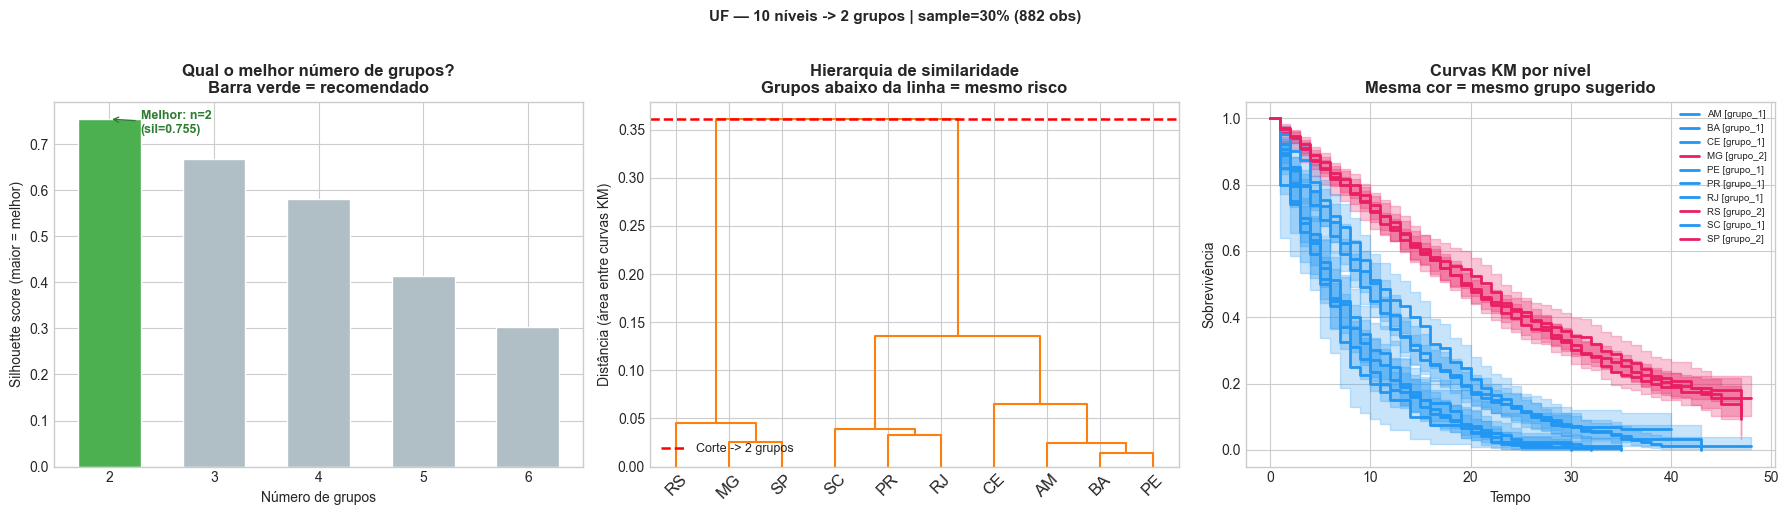


Sugestão de colapso (10 -> 2 grupos):
   grupo_1: ['AM', 'BA', 'CE', 'PE', 'PR', 'RJ', 'SC']
   grupo_2: ['MG', 'RS', 'SP']

Aplique com:
   df["uf"] = df["uf"].map(collapse_map)


In [5]:
df = make_uf_dataset(TRUE_GROUPS, UF_SIZES)

result = collapse_categorical_survival(
    df,
    category_col='uf',
    time_col='time',
    event_col='event',
    sample_pct=0.30,
    max_groups=6,
)

df['uf_colapsada'] = df['uf'].map(result['collapse_map'])

# Log Collapse Sugestion

Sample: 882 linhas (30% de 2,940)
Silhouette por n_grupos:
  n=2: 0.7546  <- melhor
  n=3: 0.6674
  n=4: 0.5812
  n=5: 0.4141


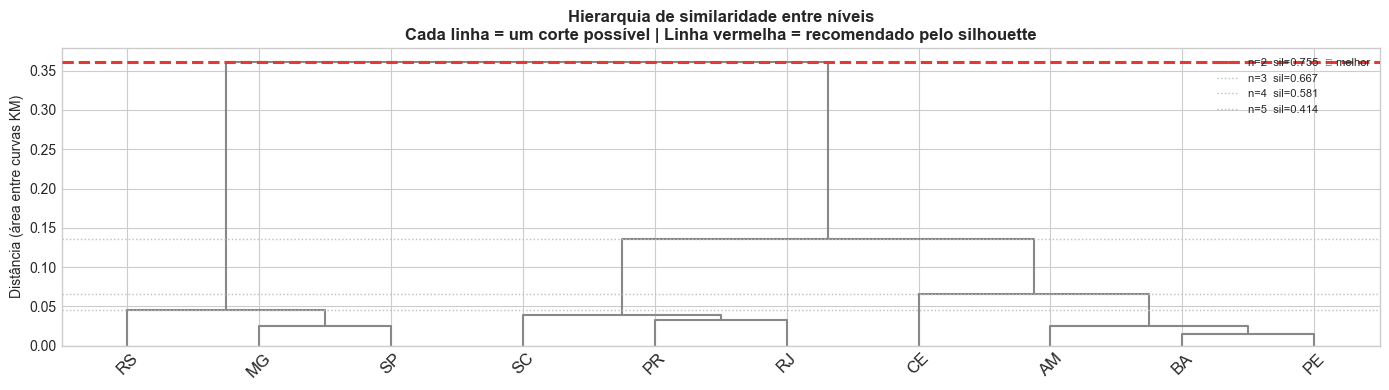

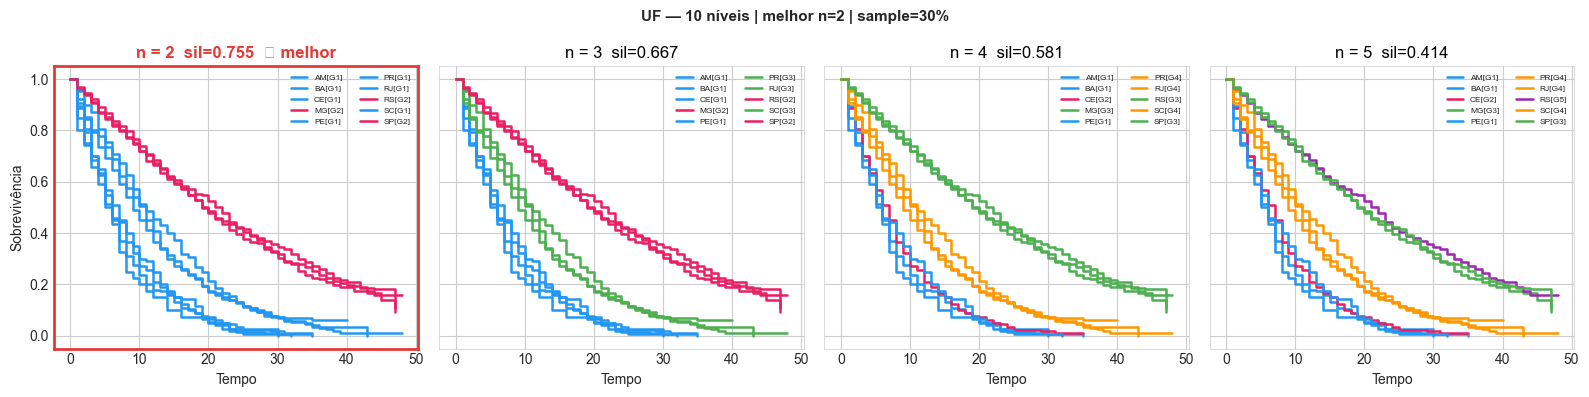


Sugestão final  (n=2):
  grupo_1: ['AM', 'BA', 'CE', 'PE', 'PR', 'RJ', 'SC']
  grupo_2: ['MG', 'RS', 'SP']

Aplique com:
  df["uf"] = df["uf"].map(collapse_map)

── decision_df ──────────────────────────────────
 n_grupos  silhouette  is_best  event_rate_min_pct  event_rate_max_pct  event_rate_spread
        2      0.7546     True                75.0               96.64              21.64
        3      0.6674    False                75.0               99.63              24.63
        4      0.5812    False                75.0              100.00              25.00
        5      0.4141    False                74.0              100.00              26.00

── detalhe do melhor n ───────────────────────────
 n_grupos   grupo  n_levels                     levels  n_obs  n_events  event_rate_pct
        2 grupo_1         7 AM, BA, CE, PE, PR, RJ, SC   1340      1295           96.64
        2 grupo_2         3                 MG, RS, SP   1600      1200           75.00
Sample: 882 linhas (3

In [6]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations
from typing import Dict, List, Optional, Tuple

from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import squareform
from sklearn.metrics import silhouette_score
from lifelines import KaplanMeierFitter

plt.style.use('seaborn-v0_8-whitegrid')
PALETTE = [
    '#2196F3', '#E91E63', '#4CAF50', '#FF9800',
    '#9C27B0', '#00BCD4', '#FF5722', '#607D8B',
]


# ─────────────────────────────────────────────────────────────────────────────
# FUNÇÕES AUXILIARES
# ─────────────────────────────────────────────────────────────────────────────

def _stratified_sample(
    df: pd.DataFrame,
    category_col: str,
    sample_pct: float,
    random_state: int,
) -> pd.DataFrame:
    """Amostragem estratificada por categoria, preservando todos os níveis."""
    return (
        df.groupby(category_col, group_keys=False)
          .apply(lambda g: g.sample(
              frac=sample_pct,
              random_state=random_state,
              replace=len(g) < 10,
          ))
    )


def _compute_km_curves(
    sample: pd.DataFrame,
    levels: List,
    category_col: str,
    time_col: str,
    event_col: str,
    times: np.ndarray,
) -> Dict:
    """Estima curva KM para cada nível no sample."""
    curves = {}
    for lv in levels:
        mask = sample[category_col] == lv
        kmf  = KaplanMeierFitter()
        kmf.fit(sample.loc[mask, time_col],
                event_observed=sample.loc[mask, event_col])
        curves[lv] = kmf.survival_function_at_times(times).values
    return curves


def _compute_distance_matrix(
    levels: List,
    km_curves: Dict,
    times: np.ndarray,
    t_max: int,
) -> np.ndarray:
    """Matriz de distância = área normalizada entre curvas KM."""
    n   = len(levels)
    idx = {lv: i for i, lv in enumerate(levels)}
    mat = np.zeros((n, n))
    for lv_a, lv_b in combinations(levels, 2):
        area = float(np.trapezoid(
            np.abs(km_curves[lv_a] - km_curves[lv_b]), times
        )) / t_max
        mat[idx[lv_a], idx[lv_b]] = area
        mat[idx[lv_b], idx[lv_a]] = area
    return mat


def _group_stats(
    df: pd.DataFrame,
    levels: List,
    category_col: str,
    event_col: str,
    collapse_map: Dict,
    n: int,
) -> pd.DataFrame:
    """
    Estatísticas descritivas por grupo para um n específico.
    Retorna uma linha por grupo com: n_levels, levels, n_obs,
    n_events, event_rate_pct.
    """
    df_mapped = df.assign(_grupo=df[category_col].map(collapse_map))
    rows = []
    for grupo, sub in df_mapped.groupby('_grupo'):
        niveis_do_grupo = sorted(
            lv for lv in levels if collapse_map.get(lv) == grupo
        )
        rows.append({
            'n_grupos'      : n,
            'grupo'         : grupo,
            'n_levels'      : len(niveis_do_grupo),
            'levels'        : ', '.join(str(l) for l in niveis_do_grupo),
            'n_obs'         : len(sub),
            'n_events'      : int(sub[event_col].sum()),
            'event_rate_pct': round(sub[event_col].mean() * 100, 2),
        })
    return pd.DataFrame(rows).sort_values('grupo').reset_index(drop=True)


def _build_decision_df(
    df: pd.DataFrame,
    levels: List,
    category_col: str,
    event_col: str,
    Z: np.ndarray,
    dist_matrix: np.ndarray,
    sil_scores: Dict,
    best_n: int,
    min_n: int,
    max_n: int,
) -> pd.DataFrame:
    """
    Constrói o DataFrame de decisão com uma linha por n_grupos testado.
    Colunas: n_grupos, silhouette, is_best, suggested_groups,
             group_stats (lista de dicts), event_rate_min/max por grupo.
    """
    rows = []
    for n in range(min_n, max_n + 1):
        labels_n    = fcluster(Z, t=n, criterion='maxclust')
        groups_n: Dict = {}
        for lv, g in zip(levels, labels_n):
            groups_n.setdefault(int(g), []).append(lv)
        suggested = list(groups_n.values())

        collapse_n = {
            lv: f'grupo_{g_idx + 1}'
            for g_idx, grp in enumerate(suggested)
            for lv in grp
        }

        stats_n = _group_stats(
            df, levels, category_col, event_col, collapse_n, n
        )

        rows.append({
            'n_grupos'         : n,
            'silhouette'       : sil_scores.get(n),
            'is_best'          : n == best_n,
            'suggested_groups' : [sorted(g) for g in suggested],
            'n_obs_por_grupo'  : stats_n.set_index('grupo')['n_obs'].to_dict(),
            'event_rate_por_grupo': (
                stats_n.set_index('grupo')['event_rate_pct'].to_dict()
            ),
            'event_rate_min_pct': stats_n['event_rate_pct'].min(),
            'event_rate_max_pct': stats_n['event_rate_pct'].max(),
            'event_rate_spread' : round(
                stats_n['event_rate_pct'].max()
                - stats_n['event_rate_pct'].min(), 2
            ),
            'group_detail'     : stats_n,
        })

    return pd.DataFrame(rows).sort_values('n_grupos').reset_index(drop=True)


# ─────────────────────────────────────────────────────────────────────────────
# PLOTS
# ─────────────────────────────────────────────────────────────────────────────

def _plot_dendrogram_row(
    ax: plt.Axes,
    Z: np.ndarray,
    levels: List,
    sil_scores: Dict,
    best_n: int,
    min_n: int,
    max_n: int,
) -> None:
    """
    Dendrograma com uma linha tracejada por n testado.
    A linha do melhor n é mais grossa e vermelha; as demais são cinza claro.
    """
    # Plota o dendrograma sem coloração automática
    dendrogram(
        Z, labels=levels, ax=ax,
        color_threshold=0,
        above_threshold_color='#888888',
        leaf_rotation=45,
    )

    # Uma linha por n — do mais alto para o mais baixo para não sobrepor labels
    for n in range(min_n, max_n + 1):
        # Altura de corte que produz exatamente n grupos
        cut = float(Z[-(n - 1), 2]) + 1e-9
        is_best = (n == best_n)
        sil_val = sil_scores.get(n)
        label   = (
            f'n={n}  sil={sil_val:.3f}{"  ◀ melhor" if is_best else ""}'
            if sil_val is not None else f'n={n}'
        )
        ax.axhline(
            cut,
            color='#E53935' if is_best else '#BDBDBD',
            linewidth=2.2 if is_best else 1.0,
            linestyle='--' if is_best else ':',
            label=label,
            zorder=3 if is_best else 2,
        )

    ax.set_title(
        'Hierarquia de similaridade entre níveis\n'
        'Cada linha = um corte possível | Linha vermelha = recomendado pelo silhouette',
        fontweight='bold',
    )
    ax.set_ylabel('Distância (área entre curvas KM)')
    ax.legend(fontsize=8, loc='upper right')


def _plot_km_row(
    axes_row: List[plt.Axes],
    df: pd.DataFrame,
    levels: List,
    category_col: str,
    time_col: str,
    event_col: str,
    Z: np.ndarray,
    sil_scores: Dict,
    best_n: int,
    min_n: int,
    max_n: int,
) -> None:
    """
    Uma curva KM por valor de n testado, colorida por grupo sugerido.
    O melhor n recebe destaque no título.
    """
    for ax, n in zip(axes_row, range(min_n, max_n + 1)):
        labels_n = fcluster(Z, t=n, criterion='maxclust')
        groups_n: Dict = {}
        for lv, g in zip(levels, labels_n):
            groups_n.setdefault(int(g), []).append(lv)
        suggested = list(groups_n.values())

        level_colors = {
            lv: PALETTE[g_idx % len(PALETTE)]
            for g_idx, grp in enumerate(suggested)
            for lv in grp
        }
        collapse_n = {
            lv: f'G{g_idx + 1}'
            for g_idx, grp in enumerate(suggested)
            for lv in grp
        }

        for lv in levels:
            mask = df[category_col] == lv
            kmf  = KaplanMeierFitter(label=f'{lv}[{collapse_n[lv]}]')
            kmf.fit(df.loc[mask, time_col],
                    event_observed=df.loc[mask, event_col])
            kmf.plot_survival_function(
                ax=ax,
                color=level_colors[lv],
                ci_show=False,
                linewidth=1.8,
            )

        sil_val  = sil_scores.get(n)
        sil_str  = f'  sil={sil_val:.3f}' if sil_val is not None else ''
        best_str = '  ◀ melhor' if n == best_n else ''
        ax.set_title(
            f'n = {n}{sil_str}{best_str}',
            fontweight='bold' if n == best_n else 'normal',
            color='#E53935' if n == best_n else 'black',
        )
        ax.set_xlabel('Tempo')
        ax.set_ylabel('Sobrevivência' if n == min_n else '')
        ax.legend(fontsize=6, ncol=2)

        # Borda vermelha no melhor
        for spine in ax.spines.values():
            spine.set_edgecolor('#E53935' if n == best_n else '#CCCCCC')
            spine.set_linewidth(2.0 if n == best_n else 0.5)


# ─────────────────────────────────────────────────────────────────────────────
# FUNÇÃO PRINCIPAL
# ─────────────────────────────────────────────────────────────────────────────

def collapse_categorical_survival(
    df: pd.DataFrame,
    category_col: str,
    time_col: str,
    event_col: str,
    sample_pct: float = 1.0,
    min_groups: int = 2,
    max_groups: Optional[int] = None,
    n_groups: Optional[int] = None,
    random_state: int = 42,
    show_plots: bool = True,
    figsize_dend: Tuple[int, int] = (14, 4),
    figsize_km_per_panel: Tuple[int, int] = (4, 4),
) -> Dict:
    """
    Identifica onde colapsar os níveis de uma categórica em survival.

    Fluxo:
      1. Amostragem estratificada (opcional, para big data)
      2. Curvas KM por nível
      3. Matriz de distância = área integrada entre curvas (invariante ao n)
      4. Clustering hierárquico
      5. Silhouette para cada n testado → escolhe o melhor
      6. Plots: dendrograma (linha) + KM por n (linha)
      7. DataFrame de decisão com silhouette, grupos e estatísticas descritivas

    Parameters
    ----------
    df                   : DataFrame completo
    category_col         : coluna categórica (ex: 'uf')
    time_col             : coluna de tempo
    event_col            : coluna de evento binário
    sample_pct           : fração usada para estimar as KMs (1.0 = tudo)
    min_groups           : menor n a testar (default 2)
    max_groups           : maior n a testar (None = n_levels - 1)
    n_groups             : força um n específico, pula a busca automática
    random_state         : semente para o sample
    show_plots           : False → pula os gráficos (modo não-visual)
    figsize_dend         : tamanho do painel do dendrograma
    figsize_km_per_panel : tamanho de cada painel KM (largura × altura)

    Returns
    -------
    dict com:
      'collapse_map'     : dict nível -> 'grupo_N' do melhor n
      'suggested_groups' : lista de listas do melhor n
      'best_n_groups'    : n recomendado
      'silhouette_scores': dict n -> score
      'distance_matrix'  : DataFrame (n_levels × n_levels)
      'decision_df'      : DataFrame com uma linha por n testado,
                           contendo silhouette, grupos sugeridos,
                           n_obs e event_rate por grupo
    """
    # ── 0. Sample ─────────────────────────────────────────────────────────────
    if sample_pct < 1.0:
        sample = _stratified_sample(df, category_col, sample_pct, random_state)
        print(f'Sample: {len(sample):,} linhas '
              f'({sample_pct:.0%} de {len(df):,})')
    else:
        sample = df

    levels = sorted(sample[category_col].dropna().unique())
    n_lvl  = len(levels)
    t_max  = int(sample[time_col].max())
    times  = np.arange(1, t_max + 1)

    # ── 1. KM + distâncias ────────────────────────────────────────────────────
    km_curves   = _compute_km_curves(
        sample, levels, category_col, time_col, event_col, times
    )
    dist_matrix = _compute_distance_matrix(levels, km_curves, times, t_max)
    Z           = linkage(squareform(dist_matrix), method='complete')

    # ── 2. Silhouette por n ───────────────────────────────────────────────────
    max_n = min(max_groups or (n_lvl - 1), n_lvl - 1)
    min_n = min_groups

    if n_groups is not None:
        best_n     = n_groups
        sil_scores = {}
        print(f'n_groups fixado em {best_n}')
    else:
        sil_scores = {}
        for k in range(min_n, max_n + 1):
            labels_k = fcluster(Z, t=k, criterion='maxclust')
            if len(np.unique(labels_k)) < 2:
                continue
            sil = silhouette_score(
                dist_matrix, labels_k, metric='precomputed'
            )
            sil_scores[k] = round(float(sil), 4)

        best_n = max(sil_scores, key=sil_scores.get)

        print('Silhouette por n_grupos:')
        for k, s in sorted(sil_scores.items()):
            marker = '  <- melhor' if k == best_n else ''
            print(f'  n={k}: {s:.4f}{marker}')

    # ── 3. Agrupamento final (best_n) ─────────────────────────────────────────
    final_labels = fcluster(Z, t=best_n, criterion='maxclust')
    groups_best: Dict = {}
    for lv, g in zip(levels, final_labels):
        groups_best.setdefault(int(g), []).append(lv)
    suggested_groups = list(groups_best.values())

    collapse_map = {
        lv: f'grupo_{g_idx + 1}'
        for g_idx, grp in enumerate(suggested_groups)
        for lv in grp
    }

    # ── 4. DataFrame de decisão ───────────────────────────────────────────────
    decision_df = _build_decision_df(
        df, levels, category_col, event_col,
        Z, dist_matrix, sil_scores, best_n, min_n, max_n,
    )

    # ── 5. Plots ──────────────────────────────────────────────────────────────
    if show_plots:
        n_panels = max_n - min_n + 1

        # Linha 1: dendrograma
        fig_dend, ax_dend = plt.subplots(1, 1, figsize=figsize_dend)
        _plot_dendrogram_row(
            ax_dend, Z, levels, sil_scores, best_n, min_n, max_n
        )
        plt.tight_layout()
        plt.show()

        # Linha 2: KM por n
        w, h   = figsize_km_per_panel
        fig_km, axes_km = plt.subplots(
            1, n_panels,
            figsize=(w * n_panels, h),
            sharey=True,
        )
        axes_km = [axes_km] if n_panels == 1 else list(axes_km)
        _plot_km_row(
            axes_km, df, levels, category_col, time_col, event_col,
            Z, sil_scores, best_n, min_n, max_n,
        )
        plt.suptitle(
            f'{category_col.upper()} — {n_lvl} níveis | '
            f'melhor n={best_n} | sample={sample_pct:.0%}',
            fontsize=11, fontweight='bold',
        )
        plt.tight_layout()
        plt.show()

    # ── 6. Sumário ────────────────────────────────────────────────────────────
    print(f'\nSugestão final  (n={best_n}):')
    for g_idx, grp in enumerate(suggested_groups):
        print(f'  grupo_{g_idx+1}: {sorted(grp)}')
    print(f'\nAplique com:')
    print(f'  df["{category_col}"] = df["{category_col}"].map(collapse_map)')

    return {
        'collapse_map'    : collapse_map,
        'suggested_groups': suggested_groups,
        'best_n_groups'   : best_n,
        'silhouette_scores': sil_scores,
        'distance_matrix' : pd.DataFrame(
            dist_matrix, index=levels, columns=levels
        ),
        'decision_df'     : decision_df,
    }


# ─────────────────────────────────────────────────────────────────────────────
# DATASET SINTÉTICO
# ─────────────────────────────────────────────────────────────────────────────

TRUE_GROUPS = {
    'baixo_risco': {'ufs': ['SP', 'MG', 'RS'],      'scale': 25.0},
    'medio_risco': {'ufs': ['RJ', 'PR', 'SC'],      'scale': 15.0},
    'alto_risco' : {'ufs': ['BA', 'CE', 'PE', 'AM'], 'scale':  8.0},
}
UF_SIZES = {
    'SP': 800, 'MG': 500, 'RS': 300,
    'RJ': 400, 'PR': 250, 'SC': 150,
    'BA': 200, 'CE': 180, 'PE': 120, 'AM': 40,
}


def make_uf_dataset(
    true_groups: Dict,
    uf_sizes: Dict,
    shape: float = 1.2,
    max_followup: int = 48,
    random_state: int = 42,
) -> pd.DataFrame:
    rng = np.random.default_rng(random_state)
    uf_to_scale = {
        uf: info['scale']
        for info in true_groups.values()
        for uf in info['ufs']
    }
    uf_to_group = {
        uf: g
        for g, info in true_groups.items()
        for uf in info['ufs']
    }
    rows = []
    for uf, n in uf_sizes.items():
        noise   = rng.uniform(0.85, 1.15)
        t_event = rng.weibull(shape, n) * uf_to_scale[uf] * noise
        t_cens  = rng.uniform(max_followup * 0.5, max_followup, n)
        t_obs   = np.clip(
            np.round(np.minimum(t_event, t_cens)).astype(int),
            1, max_followup,
        )
        evento = (t_event <= t_cens).astype(int)
        for i in range(n):
            rows.append({
                'id'              : f'{uf}_{i}',
                'uf'              : uf,
                'grupo_verdadeiro': uf_to_group[uf],
                'time'            : t_obs[i],
                'event'           : evento[i],
            })
    return (
        pd.DataFrame(rows)
          .sample(frac=1, random_state=random_state)
          .reset_index(drop=True)
    )


# ─────────────────────────────────────────────────────────────────────────────
# DEMO
# ─────────────────────────────────────────────────────────────────────────────

if __name__ == '__main__':
    df = make_uf_dataset(TRUE_GROUPS, UF_SIZES)

    # Com gráficos
    result = collapse_categorical_survival(
        df,
        category_col='uf',
        time_col='time',
        event_col='event',
        sample_pct=0.30,
        min_groups=2,
        max_groups=5,
        show_plots=True,
    )

    print('\n── decision_df ──────────────────────────────────')
    cols = ['n_grupos', 'silhouette', 'is_best',
            'event_rate_min_pct', 'event_rate_max_pct', 'event_rate_spread']
    print(result['decision_df'][cols].to_string(index=False))

    print('\n── detalhe do melhor n ───────────────────────────')
    best_detail = result['decision_df'].loc[
        result['decision_df']['is_best'], 'group_detail'
    ].values[0]
    print(best_detail.to_string(index=False))

    # Sem gráficos (modo não-visual para automação/auditoria)
    result_silent = collapse_categorical_survival(
        df,
        category_col='uf',
        time_col='time',
        event_col='event',
        sample_pct=0.30,
        max_groups=5,
        show_plots=False,
    )
    print('\nModo silencioso — decision_df disponível:')
    print(result_silent['decision_df'][cols].to_string(index=False))